
# GRUPO 07
## Segunda Preentrega

Se realiza la Exploración, la Transformación y la Visualización de datos con Pandas sobre el CSV de **"Datos de fractura de pozos de hidrocarburos"**, subido en la base de datos del datos.gob.ar.

### Contexto del Dominio del Dataset
El dataset contiene el registro público que presentan las empresas operadoras ante la Secretaría de Energía sobre cada intervención de **estimulación hidráulica (fracking)** realizada en el territorio argentino.


## Parte 1: Análisis Exploratorio de los Datos (EDA)

### Paso 1.1: Carga del Dataset e Ingesta Inicial
Importamos las librerías a usar e invocamos el dataset.

In [596]:
# Importamos las librerías a utilizar durante el EDA
import pandas as pd
import numpy as np
import matplotlib as pyplot
import seaborn as sns
import matplotlib.pyplot as plt

# Realizamos la ingesta del dataset con formato .csv
df=pd.read_csv('/content/Base de Datos - Pozos Petroleros.csv')


### Paso 1.2: Reconocimiento del Dataset (Estructura y Tipos de Datos)
Analizamos la cantidad de filas y columnas, qué representa cada registro, los tipos de datos de cada variable, y si existen faltantes o duplicados preliminares.



#### Cantidad de filas y columnas:


In [597]:
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset tiene 4890 filas y 31 columnas.


In [598]:
df.head(5)

,_id,id_base_fractura_adjiv,idpozo,sigla,cuenca,areapermisoconcesion,yacimiento,formacion_productiva,tipo_reservorio,subtipo_reservorio,longitud_rama_horizontal_m,cantidad_fracturas,tipo_terminacion,arena_bombeada_nacional_tn,arena_bombeada_importada_tn,agua_inyectada_m3,co2_inyectado_m3,presion_maxima_psi,potencia_equipos_fractura_hp,fecha_inicio_fractura,fecha_fin_fractura,fecha_data,anio_if,mes_if,anio_ff,mes_ff,anio_carga,mes_carga,empresa_informante,mes,anio
0,1,30,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.0,3,Punzado,0.000,0.000,2718.20,0.0,10190.0,10897.0,2019-04-20T00:00:00,2019-04-30T00:00:00,2019-06-14T17:13:03,2019,4,2019,4,2019,6,CAPEX S.A.,4,2019
1,2,31,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.0,1,Punzado,0.000,0.000,600.00,0.0,9250.0,10251.0,2018-11-02T00:00:00,2018-11-03T00:00:00,2019-06-14T17:14:19,2018,11,2018,11,2019,6,CAPEX S.A.,11,2018
2,3,37,159219,YPF.Nq.AdlA-1001(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1437.3,18,Tapón disparo,3761.370,536.850,25768.30,0.0,15000.0,32000.0,2017-11-19T00:00:00,2017-12-14T00:00:00,2019-06-27T13:46:21,2017,11,2017,12,2019,6,YPF S.A.,11,2017
3,4,38,159220,YPF.Nq.AdlA-1002(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1518.3,19,Tapón disparo,3903.705,558.225,27398.37,0.0,11348.0,32000.0,2017-11-21T00:00:00,2017-12-15T00:00:00,2019-06-27T13:46:21,2017,11,2017,12,2019,6,YPF S.A.,11,2017
4,5,39,159221,YPF.Nq.AdlA-1003(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1482.3,19,Tapón disparo,3949.020,569.925,27157.60,0.0,11076.0,32000.0,2017-11-18T00:00:00,2017-12-15T00:00:00,2019-06-27T13:46:21,2017,11,2017,12,2019,6,YPF S.A.,11,2017


Cada una de las filas representa una fractura de un pozo petrolífero, y las columnas cuentan qué pozo era, dónde estaba y cómo se hizo esa fractura.

In [599]:
df.dtypes

,0
_id,int64
id_base_fractura_adjiv,int64
idpozo,int64
sigla,object
cuenca,object
areapermisoconcesion,object
yacimiento,object
formacion_productiva,object
tipo_reservorio,object
subtipo_reservorio,object


Cada una de las columnas tiene el tipo de dato correspondiente, a excepción de las fechas: "fecha_inicio_fractura", "fecha_fin_fractura" y "fecha_data" están como "object" y deberían ser "datetime". Además, varias columnas de año y mes podrían quedar absorbidas por las fechas para no tener una tabla tan extensa.

#### Estadística descriptiva de las variables numéricas:

In [600]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
_id,4890.0,2445.500000,1411.765738,1.0,1223.2500,2445.500000,3667.750000,4890.000000
id_base_fractura_adjiv,4890.0,2941.261963,1647.204061,30.0,1557.2500,3052.500000,4363.750000,5669.000000
idpozo,4890.0,152128.697137,30650.102317,458.0,154557.2500,160938.500000,164468.750000,167526.000000
longitud_rama_horizontal_m,4890.0,1338.154295,1362.947854,0.0,0.0000,1251.500000,2569.500000,5114.110000
cantidad_fracturas,4890.0,23.068507,21.381275,1.0,3.0000,17.000000,41.000000,105.000000
arena_bombeada_nacional_tn,4890.0,4732.518134,5204.797057,0.0,0.0000,1974.270000,9485.954546,20834.000000
arena_bombeada_importada_tn,4890.0,346.178935,1764.375663,0.0,0.0000,9.100000,386.358750,80652.000000
agua_inyectada_m3,4890.0,32444.025100,36478.744126,0.0,454.7475,18722.475000,60648.000000,537184.600000
co2_inyectado_m3,4890.0,5.467397,37.431623,0.0,0.0000,0.000000,0.000000,560.000000
presion_maxima_psi,4890.0,9270.157632,6293.332155,0.0,6838.0000,10932.601947,11774.784187,209640.559334



### Paso 1.3: Identificación y Clasificación de Variables
Clasificamos las columnas en variables numéricas, categóricas, temporales, identificadores y texto descriptivo.


### Diccionario de variables

| Variable | Significado esperado | Tipo conceptual |
|---|---|---|
| `_id` | Identificador correlativo interno de la fila | Identificador |
| `id_base_fractura_adjiv` | Identificador interno para vincular con otras tablas de la base original | Identificador |
| `idpozo` | Identificador único del pozo | Identificador |
| `sigla` | Código o matrícula del pozo en la industria | Identificador |
| `cuenca` | Cuenca sedimentaria donde está el pozo | Categórica |
| `areapermisoconcesion` | Área de permiso o concesión de explotación | Categórica |
| `yacimiento` | Yacimiento específico dentro de la concesión | Categórica |
| `formacion_productiva` | Formación geológica de la que se extrae el hidrocarburo | Categórica |
| `tipo_reservorio` | Convencional o no convencional | Categórica |
| `subtipo_reservorio` | Subtipo dentro del tipo de reservorio (ej. shale) | Categórica |
| `longitud_rama_horizontal_m` | Metros de la sección horizontal del pozo | Numérica |
| `cantidad_fracturas` | Cantidad de etapas de fractura realizadas | Numérica discreta |
| `tipo_terminacion` | Técnica de terminación del pozo | Categórica |
| `arena_bombeada_nacional_tn` | Toneladas de arena nacional bombeadas | Numérica |
| `arena_bombeada_importada_tn` | Toneladas de arena importada bombeadas | Numérica |
| `agua_inyectada_m3` | Metros cúbicos de agua inyectados | Numérica |
| `co2_inyectado_m3` | Metros cúbicos de CO2 inyectados | Numérica |
| `presion_maxima_psi` | Presión máxima alcanzada, en psi | Numérica |
| `potencia_equipos_fractura_hp` | Potencia de los equipos de fractura, en HP | Numérica |
| `fecha_inicio_fractura` | Fecha y hora de inicio de la fractura | Temporal |
| `fecha_fin_fractura` | Fecha y hora de fin de la fractura | Temporal |
| `fecha_data` | Fecha y hora de carga/actualización del registro | Temporal |
| `anio_if` | Año de inicio de fractura | Numérica discreta |
| `mes_if` | Mes de inicio de fractura | Numérica discreta |
| `anio_ff` | Año de fin de fractura | Numérica discreta |
| `mes_ff` | Mes de fin de fractura | Numérica discreta |
| `anio_carga` | Año de carga del registro | Numérica discreta |
| `mes_carga` | Mes de carga del registro | Numérica discreta |
| `empresa_informante` | Empresa que reportó la operación | Categórica |
| `mes` | Mes de referencia del registro | Numérica discreta |
| `anio` | Año de referencia del registro | Numérica discreta |


### Paso 1.4: Análisis de Completitud y Datos Faltantes
Verificamos los datos faltantes para analizar su impacto sobre las estadísticas descriptivas, conteos y gráficos.


In [601]:
# Totalidad de los datos faltantes sobre cada columna
display('Valores faltantes:',df.isnull().sum())

'Valores faltantes:'

,0
_id,0
id_base_fractura_adjiv,0
idpozo,0
sigla,0
cuenca,0
areapermisoconcesion,0
yacimiento,0
formacion_productiva,0
tipo_reservorio,35
subtipo_reservorio,974


In [602]:
# Porcentaje que representan esos datos nulos sobre la totalidad de los datos
(df.isna().mean() * 100).sort_values(ascending=False)

,0
subtipo_reservorio,19.918200
potencia_equipos_fractura_hp,1.042945
tipo_reservorio,0.715746
sigla,0.000000
cuenca,0.000000
id_base_fractura_adjiv,0.000000
_id,0.000000
yacimiento,0.000000
areapermisoconcesion,0.000000
formacion_productiva,0.000000


Queríamos ver en qué tipo de registros faltaba el "tipo_reservorio":

In [603]:
# cuanca y formacion con reservorio sin definir (nulos o no discriminados)
sin_tipo = df['tipo_reservorio'].isna() | (df['tipo_reservorio'] == 'NO DISCRIMINADO')
display(df.loc[sin_tipo].groupby(['cuenca', 'formacion_productiva']).size())

# clasificacion de las formaciones dentro del dataset
formaciones_sin_tipo = df.loc[sin_tipo, 'formacion_productiva'].unique()
pd.crosstab(df['formacion_productiva'], df['tipo_reservorio'].fillna('NaN')).loc[formaciones_sin_tipo]

cuenca           formacion_productiva  
AUSTRAL          springhill                4
GOLFO SAN JORGE  castillo                  8
                 cañadon seco              2
                 comodoro rivadavia        4
                 mina el carmen            4
NEUQUINA         agrio                     1
                 formación improductiva    1
                 huitrín                   4
                 precuyo                   7
                 vaca muerta               1
dtype: int64

tipo_reservorio,CONVENCIONAL,NO CONVENCIONAL,NO DISCRIMINADO,NaN
formacion_productiva,,,,
springhill,1,2,0,4
huitrín,147,0,0,4
agrio,15,52,0,1
formación improductiva,2,2,0,1
precuyo,26,41,0,7
mina el carmen,331,1,0,4
comodoro rivadavia,173,0,0,4
cañadon seco,35,0,0,2
castillo,0,0,0,8


La mayoría de los tipos faltantes son de formaciones que en el resto del dataset son convencionales. Si los completáramos con la moda global ("NO CONVENCIONAL"), estaríamos clasificando mal pozos convencionales. Habria que imputar por la cuenca y la formacion.


### Paso 1.5: Análisis de Redundancia Temporal
Las columnas de "fecha_inicio_fractura", "fecha_fin_fractura" y "fecha_data" tienen un formato de año-mes-día y hora. Evaluaremos si es posible prescindir de las columnas de año/mes de carga si coinciden con los registros temporales originales.

In [604]:
fecha_data_dt = pd.to_datetime(df['fecha_data'])

# Verificamos si el año y el mes de fecha_data coinciden con anio_carga y mes_carga
coincide_anio_carga = (fecha_data_dt.dt.year == df['anio_carga'])
coincide_mes_carga = (fecha_data_dt.dt.month == df['mes_carga'])
print(f"Coinciden todos los años: {coincide_anio_carga.all()} | Filas distintas: {(~coincide_anio_carga).sum()}")
print(f"Coinciden todos los meses: {coincide_mes_carga.all()} | Filas distintas: {(~coincide_mes_carga).sum()}")

# Verificamos también si mes/anio repiten a mes_if/anio_if
print(f"mes == mes_if en todas las filas: {(df['mes'] == df['mes_if']).all()}")
print(f"anio == anio_if en todas las filas: {(df['anio'] == df['anio_if']).all()}")

Coinciden todos los años: True | Filas distintas: 0
Coinciden todos los meses: True | Filas distintas: 0
mes == mes_if en todas las filas: True
anio == anio_if en todas las filas: True



También analizamos si existen registros tales como que la fecha de inicio de la fractura sea posterior a la fecha de fin de la misma:

In [605]:
fecha_inicio_eda = pd.to_datetime(df['fecha_inicio_fractura'])
fecha_fin_eda = pd.to_datetime(df['fecha_fin_fractura'])
duracion_eda = (fecha_fin_eda - fecha_inicio_eda).dt.days

print(f"Registros con fechas invertidas: {(duracion_eda < 0).sum()}")
print(f"Registros con duración mayor a un año: {(duracion_eda > 365).sum()}")
display(duracion_eda[(duracion_eda >= 0) & (duracion_eda <= 365)].describe())

Registros con fechas invertidas: 41
Registros con duración mayor a un año: 21


,0
count,4828.000000
mean,17.805095
std,27.887071
min,0.000000
25%,3.000000
50%,13.000000
75%,24.000000
max,356.000000


In [606]:
fechas_anomalas_eda = (duracion_eda < 0) | (duracion_eda > 365)
(
    df.loc[fechas_anomalas_eda, ['sigla', 'fecha_inicio_fractura', 'fecha_fin_fractura', 'fecha_data']]
    .assign(duracion_dias=duracion_eda[fechas_anomalas_eda])
    .sort_values('duracion_dias')
)

,sigla,fecha_inicio_fractura,fecha_fin_fractura,fecha_data,duracion_dias
723,CGC.SCA.CI-1010(h),2019-09-07T00:00:00,2018-09-10T00:00:00,2019-07-26T16:35:14,-362
3321,PAE.Nq.APO-115(h),2022-12-29T00:00:00,2022-01-11T00:00:00,2023-03-14T14:35:50,-352
2992,WIN.Nq.AF-102(h),2022-05-08T00:00:00,2021-05-21T00:00:00,2022-06-30T12:48:06,-352
2993,WIN.Nq.AF-202(h),2022-05-08T00:00:00,2021-05-21T00:00:00,2022-06-30T12:49:18,-352
3398,TAU.Nq.AP-1056(h),2022-12-24T00:00:00,2022-01-12T00:00:00,2023-05-05T17:10:51,-346
...,...,...,...,...,...
2776,YPF.Nq.LACh-157(h),2019-12-13T00:00:00,2021-07-14T00:00:00,2021-09-22T14:52:30,579
2780,YPF.Nq.LACh-161(h),2019-12-13T00:00:00,2021-07-14T00:00:00,2021-09-22T14:52:30,579
2778,YPF.Nq.LACh-159(h),2019-12-13T00:00:00,2021-07-15T00:00:00,2021-09-22T14:52:30,580
4207,CHA.Nq.ETE-2404(h),2024-01-15T00:00:00,2025-11-01T00:00:00,2025-07-17T15:28:30,656


Una fractura dura típicamente unas dos semanas (mediana de 13 días).

### Paso 1.6: Análisis de Registros Duplicados

In [607]:
cantidad_duplicados = df.duplicated().sum()
print(f"Cantidad de registros completamente duplicados detectados: {cantidad_duplicados}")

Cantidad de registros completamente duplicados detectados: 0


### Paso 1.7: Exploración de Variables Categóricas y Cardinalidad
Análisis de distribución de cuencas, yacimientos y normalización de textos.

In [608]:
df["cuenca"].unique()

array(['NEUQUINA', 'AUSTRAL', 'GOLFO SAN JORGE'], dtype=object)

In [609]:
display(df["areapermisoconcesion"].unique())
len(df["areapermisoconcesion"].unique())

array(['AGUA DEL CAJON', 'AGUADA DE LA ARENA', 'EL OREJANO',
       'LA AMARGA CHICA', 'BANDURRIA SUR', 'LOMA CAMPANA',
       'LA RIBERA BLOQUE I ', 'RINCON DEL MANGRULLO',
       'CAMPO INDIO ESTE - EL CERRITO ', 'SIERRAS BLANCAS',
       'BAJADA DE AÑELO', 'COIRON AMARGO SUR OESTE', 'CRUZ DE LORENA',
       'SANTA CRUZ I - FRACCION C', 'LA CALERA', 'EL TRAPIAL - CURAMCHED',
       'EL TRAPIAL ESTE', 'AL NORTE DE LA DORSAL', 'LAS MANADAS',
       'FILO MORADO', 'LA ANGOSTURA SUR II', 'ESTACION FERNANDEZ ORO',
       'LOMA LA LATA - SIERRA BARROSA', 'BAJADA DEL PALO OESTE',
       'LA ANGOSTURA SUR I', 'RIO NEUQUEN', 'AGUADA DE CASTRO  ',
       'AGUADA PICHANA OESTE ', 'BANDURRIA CENTRO',
       'COIRON AMARGO SUR ESTE', 'LINDERO ATRAVESADO', 'AGUADA FEDERAL',
       'BANDURRIA NORTE', 'CN-V', 'BAJO DEL CHOIQUE - LA INVERNADA',
       'LOS TOLDOS II OESTE', 'PUESTO ROJAS', 'FORTIN DE PIEDRA ',
       'EL TORDILLO', 'AGUA SALADA', 'LOMA RANQUELES',
       'ESTANCIA LA MARIPOSA', 'PUES

106

In [610]:
import difflib
yacimientos=df["yacimiento"].unique()

####>>>> Esto que sigue no sabiamos armarlo, por lo que usamos IA
umbral_similitud = 0.80  # de 0 a 1: cuanto más cerca de 1, más exigente sos con "parecido"

yacimientos_normalizados = [str(y).lower().strip() for y in yacimientos] # Added this line

parecidos = []

for i in range(len(yacimientos_normalizados)):
    for j in range(i + 1, len(yacimientos_normalizados)):
        similitud = difflib.SequenceMatcher(
            None, yacimientos_normalizados[i], yacimientos_normalizados[j]
        ).ratio()
        if similitud >= umbral_similitud:
            parecidos.append((yacimientos_normalizados[i], yacimientos_normalizados[j], round(similitud, 2)))

for par in parecidos:
    print(par)

('loma campana-lll', 'loma campana', 0.86)
('el cerrito oeste', 'el cerrito norte', 0.88)
('coiron amargo sur oeste', 'coiron amargo sur este', 0.98)
('el trapial', 'el trapial este', 0.8)
('la angostura sur ii', 'la angostura sur i', 0.97)
('aguada de castro', 'aguada del chivato', 0.82)
('lindero atravesado occidental', 'lindero atravesado oriental', 0.93)
('estancia la mariposa', 'estancia campos', 0.8)
('puesto quiroga', 'puesto quiroga oeste', 0.82)
('aguada de los indios sur', 'aguada de los indios', 0.91)
('puesto parada', 'puesto parada nc', 0.9)
('loma negra ni', 'loma negra', 0.87)
('pampa de las yeguas ii', 'pampa de las yeguas i', 0.98)
('bajo del toro norte', 'bajo del toro', 0.81)
('bajada del palo oeste', 'bajada del palo este', 0.98)
('loma colorada', 'loma cortada', 0.88)
('confluencia norte', 'confluencia sur', 0.81)


Estos pares, en principio, podrían ser el mismo yacimiento:

- loma campana-lll y loma campana
- el trapial y el trapial este
- puesto quiroga y puesto quiroga oeste
- aguada de los indios sur y aguada de los indios
- puesto parada y puesto parada nc
- loma negra ni y loma negra
- bajo del toro norte y bajo del toro

No los unificamos: según lo consultado con IA, ninguno de estos siete pares parece ser un error de formato, sino yacimientos o sectores distintos.

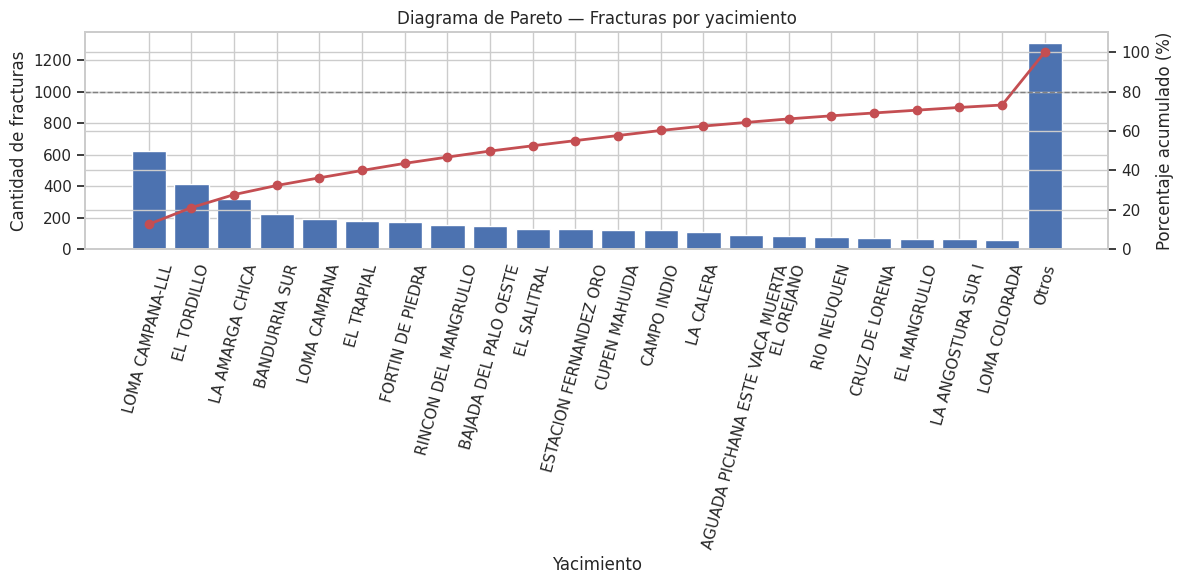

In [611]:
# Analisis PAreto hecho con IA, no nos sirvio hacer un grafico normal de
# frecuencias porque eran demasiadas como para que entren comodamente


# Cantidad de fracturas por yacimiento, de mayor a menor
conteo = df['yacimiento'].value_counts()

# Nos quedamos con los top 21 y agrupamos el resto en "Otros"
top_n = 21
top = conteo[:top_n]
otros = conteo[top_n:].sum()
conteo_pareto = pd.concat([top, pd.Series({'Otros': otros})])

# Porcentaje acumulado
porcentaje_acumulado = conteo_pareto.cumsum() / conteo_pareto.sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras: cantidad de fracturas por yacimiento
ax1.bar(conteo_pareto.index, conteo_pareto.values, color='#4C72B0')
ax1.set_xlabel('Yacimiento')
ax1.set_ylabel('Cantidad de fracturas')
ax1.tick_params(axis='x', rotation=75)

# Segundo eje: línea de porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(conteo_pareto.index, porcentaje_acumulado.values, color='#C44E52', marker='o', linewidth=2)
ax2.set_ylabel('Porcentaje acumulado (%)')
ax2.set_ylim(0, 110)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)  # línea de referencia del 80%

plt.title('Diagrama de Pareto — Fracturas por yacimiento')
plt.tight_layout()
plt.show()

In [612]:
df["formacion_productiva"].unique()

array(['los molles', 'vaca muerta', 'magallanes', 'springhill', 'ANITA',
       'agrio', 'huitrín', 'rayoso', 'formación improductiva', 'lajas',
       'precuyo', 'lotena', 'mulichinco', 'punta rosada', 'grupo neuquén',
       'chachao', 'mina el carmen', 'comodoro rivadavia', 'loma montosa',
       'el trebol', 'sierras blancas', 'quintuco', 'tordillo',
       'palermo aike', 'cañadon seco', 'pozo d-129', 'bajo barreal',
       'castillo'], dtype=object)

ANITA es la formación Anita (cuenca Austral); sólo difiere del resto en que está en mayúsculas.

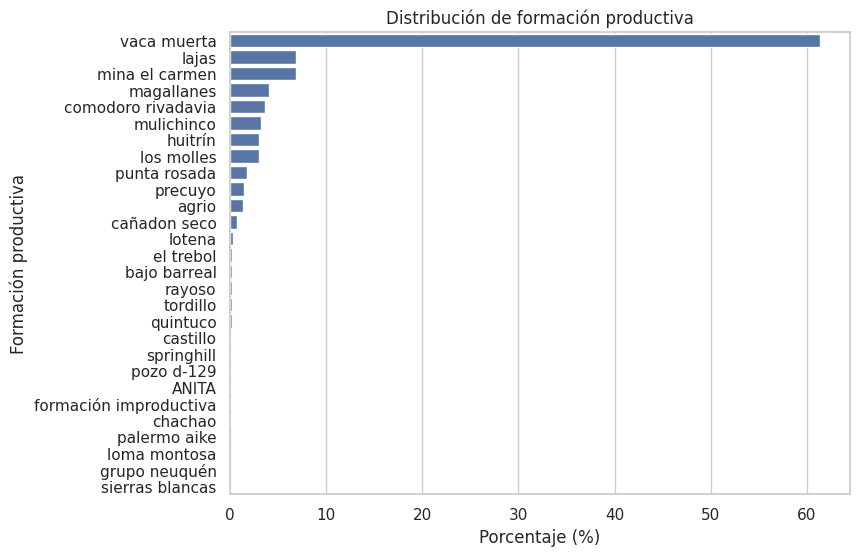

In [613]:
formacion_productiva=df['formacion_productiva']
formacion_productivas=df['formacion_productiva'].value_counts(normalize=True)*100
#formacion_productivas
#sns.countplot(y=formacion_productivas, order= formacion_productiva.value_counts().index)

plt.figure(figsize=(8,6))
sns.barplot(x=formacion_productivas.values, y=formacion_productivas.index, order=formacion_productivas.index)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Formación productiva')
plt.title('Distribución de formación productiva')
plt.show()


In [614]:
df["tipo_reservorio"].unique()

array(['NO CONVENCIONAL', nan, 'CONVENCIONAL', 'NO DISCRIMINADO'],
      dtype=object)

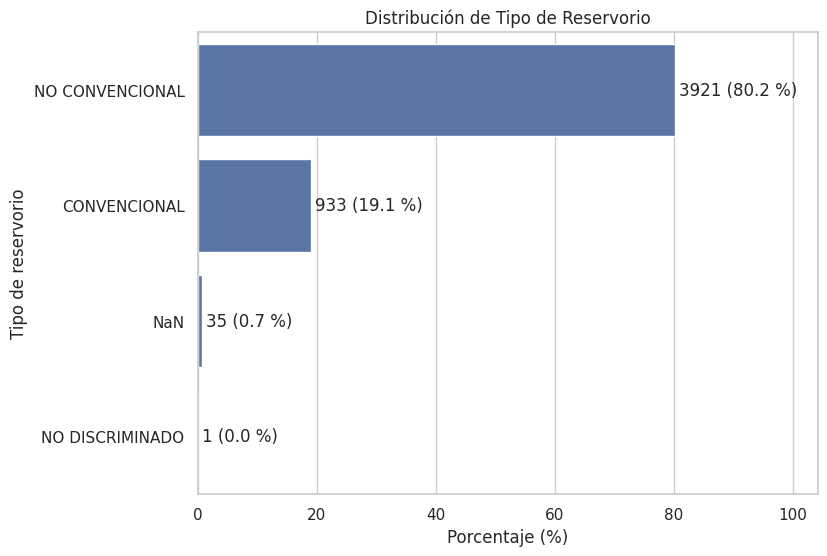

In [615]:
tipo_reservorio_conteo = df['tipo_reservorio'].fillna('NaN').value_counts()
tipo_reservorios = tipo_reservorio_conteo / tipo_reservorio_conteo.sum() * 100

plt.figure(figsize=(8,6))
ax = sns.barplot(x=tipo_reservorios.values, y=tipo_reservorios.index, order=tipo_reservorios.index)
# Etiqueta de cada barra: cantidad de registros y porcentaje
ax.bar_label(ax.containers[0], labels=[f'{n} ({p:.1f} %)' for n, p in zip(tipo_reservorio_conteo, tipo_reservorios)], padding=3)
plt.xlim(0, tipo_reservorios.max() * 1.3)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Tipo de reservorio')
plt.title('Distribución de Tipo de Reservorio')
plt.show()

Como muestra el gráfico, hay 35 NaN y 1 "NO DISCRIMINADO". Como vimos en el Paso 1.4, no los completamos con la moda global sino según la cuenca y la formación (Paso 2.3).

In [616]:
df["subtipo_reservorio"].unique()

array(['SHALE', 'TIGHT', nan], dtype=object)

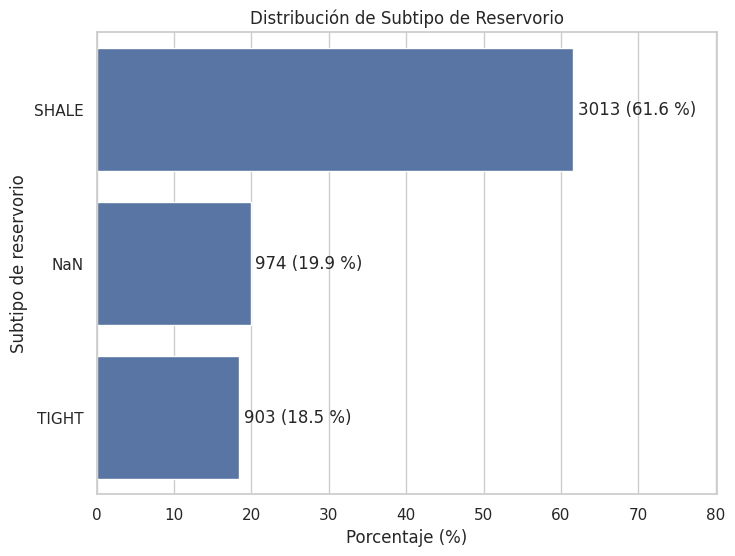

In [617]:
subtipo_reservorio_conteo = df['subtipo_reservorio'].fillna('NaN').value_counts()
subtipo_reservorios = subtipo_reservorio_conteo / subtipo_reservorio_conteo.sum() * 100

plt.figure(figsize=(8,6))
ax = sns.barplot(x=subtipo_reservorios.values, y=subtipo_reservorios.index, order=subtipo_reservorios.index)
# Etiqueta de cada barra: cantidad de registros y porcentaje
ax.bar_label(ax.containers[0], labels=[f'{n} ({p:.1f} %)' for n, p in zip(subtipo_reservorio_conteo, subtipo_reservorios)], padding=3)
plt.xlim(0, subtipo_reservorios.max() * 1.3)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Subtipo de reservorio')
plt.title('Distribución de Subtipo de Reservorio')
plt.show()

Veamos a qué tipo de reservorio corresponden los subtipos faltantes:

In [618]:
pd.crosstab(df['tipo_reservorio'].fillna('NaN'), df['subtipo_reservorio'].fillna('NaN'))

subtipo_reservorio,NaN,SHALE,TIGHT
tipo_reservorio,,,
CONVENCIONAL,933,0,0
NO CONVENCIONAL,5,3013,903
NO DISCRIMINADO,1,0,0
NaN,35,0,0


El subtipo sólo aplica a los reservorios no convencionales. En la tabla se ve que 933 de los 974 subtipos faltantes son convencionales: no tienen subtipo, y eso no es un faltante. Los 41 restantes son 5 no convencionales, 1 "NO DISCRIMINADO" y los 35 sin tipo de reservorio.

En el Paso 2.3 los convencionales pasan a "no corresponde" y los no convencionales sin subtipo toman el más frecuente de su cuenca y formación.

In [619]:
df["tipo_terminacion"].unique()

array(['Punzado', 'Tapón disparo', 'Camisas deslizables', 'Jetteo',
       'Camisas y punzados'], dtype=object)

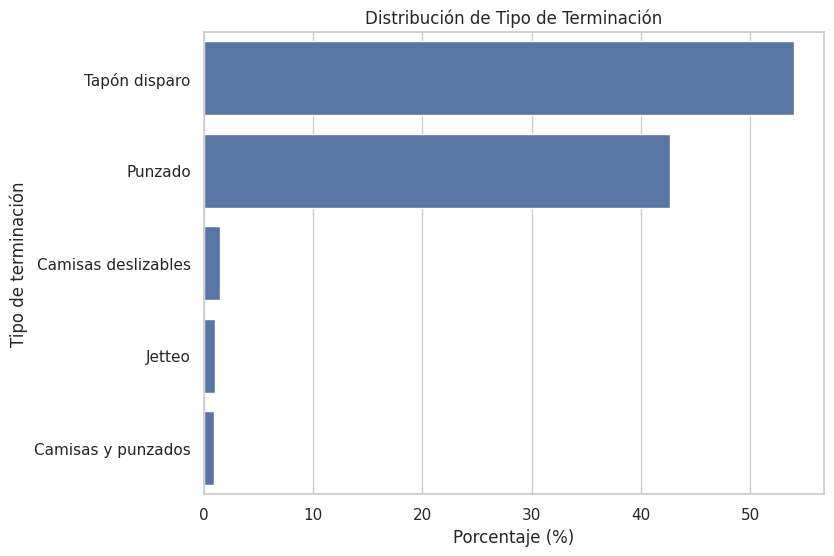

In [620]:
tt=df['tipo_terminacion']
tts=df['tipo_terminacion'].value_counts(normalize=True)*100

plt.figure(figsize=(8,6))
sns.barplot(x=tts.values, y=tts.index, order=tts.index)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Tipo de terminación')
plt.title('Distribución de Tipo de Terminación')
plt.show()

In [621]:
df["empresa_informante"].unique()

array(['CAPEX S.A.', 'YPF S.A.', 'COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.',
       'SHELL ARGENTINA S.A.', 'PLUSPETROL S.A.',
       'CHEVRON ARGENTINA S.R.L.', 'VISTA OIL & GAS ARGENTINA SAU',
       'PAN AMERICAN ENERGY SL', 'WINTERSHALL DEA ARGENTINA S.A',
       'EXXONMOBIL EXPLORATION ARGENTINA S.R.L.',
       'PETROLERA EL TREBOL S.A.', 'TECPETROL S.A.', 'MEDANITO S.A.',
       'OILSTONE ENERGIA S.A.', 'PAMPA ENERGIA S.A.',
       'TOTAL AUSTRAL S.A.', 'COMPAÑÍAS ASOCIADAS PETROLERAS S.A.',
       'VISTA ENERGY ARGENTINA SAU',
       'SINOPEC ARGENTINA EXPLORATION AND PRODUCTION, INC.',
       'CGC ENERGIA SAU', 'GEOPARK ARGENTINA S.A.',
       'PLUSPETROL CUENCA NEUQUINA S.R.L.',
       'PHOENIX GLOBAL RESOURCES S.A.'], dtype=object)

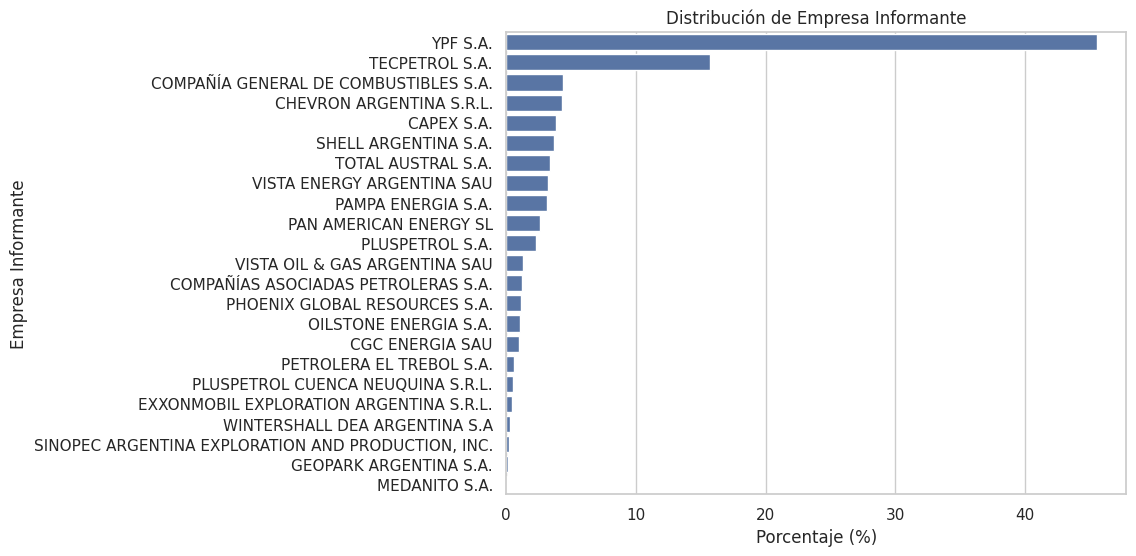

In [622]:
ei=df['empresa_informante']
eis=df['empresa_informante'].value_counts(normalize=True)*100

plt.figure(figsize=(8,6))
sns.barplot(x=eis.values, y=eis.index, order=eis.index)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Empresa Informante')
plt.title('Distribución de Empresa Informante')
plt.show()

- VISTA OIL & GAS ARGENTINA SAU y VISTA ENERGY ARGENTINA SAU son la misma empresa con cambio de nombre: se combinan.
- PLUSPETROL S.A. y PLUSPETROL CUENCA NEUQUINA S.R.L. son razones sociales distintas: no se combinan.

### Paso 1.8: Análisis Exploratorio de Variables Numéricas y Outliers
Revisión detallada de variables clave como longitud de rama, cantidad de fracturas, presiones y fluidos para identificar anomalías físicas e inconsistencias de registro.

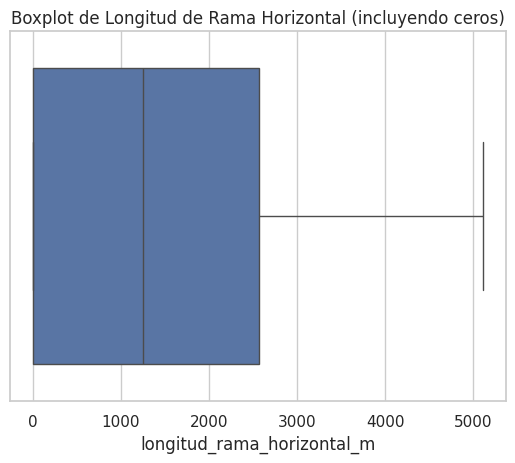

In [623]:
sns.boxplot(data=df , x='longitud_rama_horizontal_m')
plt.title('Boxplot de Longitud de Rama Horizontal (incluyendo ceros)')
plt.show()

El boxplot anterior está dominado por la gran cantidad de valores cero. Para entender mejor la distribución de la longitud de las ramas horizontales cuando son mayores a cero, visualicemos un boxplot excluyendo estos valores.

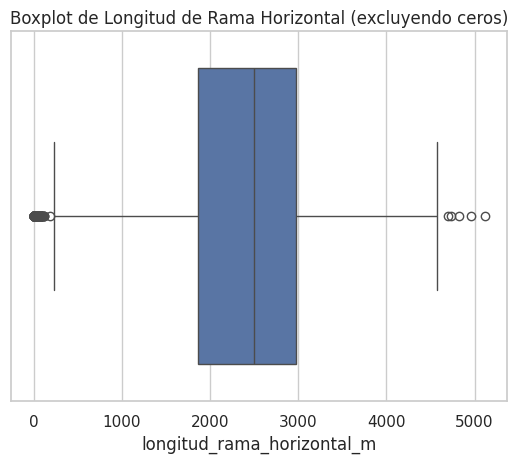

In [624]:
df_non_zero_horizontal_length = df[df['longitud_rama_horizontal_m'] > 0]
sns.boxplot(data=df_non_zero_horizontal_length, x='longitud_rama_horizontal_m')
plt.title('Boxplot de Longitud de Rama Horizontal (excluyendo ceros)')
plt.show()

El boxplot muestra atípicos de los dos lados. Calculamos los límites con el criterio IQR y revisamos qué registros quedan fuera:

In [625]:
# Límites de atípicos (criterio IQR) sobre las ramas mayores a 0
rama = df_non_zero_horizontal_length['longitud_rama_horizontal_m']
Q1_rama = rama.quantile(0.25)
Q3_rama = rama.quantile(0.75)
IQR_rama = Q3_rama - Q1_rama
limite_inferior_rama = Q1_rama - 1.5 * IQR_rama
limite_superior_rama = Q3_rama + 1.5 * IQR_rama
print(f"Límite inferior: {limite_inferior_rama:.1f} m | Límite superior: {limite_superior_rama:.1f} m")

rama_alta = df_non_zero_horizontal_length[rama > limite_superior_rama]
rama_baja = df_non_zero_horizontal_length[rama < limite_inferior_rama]
es_h_baja = rama_baja['sigla'].str.contains(r'\(h\)', na=False)
print(f"Atípicos altos: {len(rama_alta)}")
print(f"Atípicos bajos: {len(rama_baja)} ({es_h_baja.sum()} marcados como horizontales (h), {(~es_h_baja).sum()} sin (h))")

# Atípicos altos: metros de rama por etapa, para comparar con el espaciado típico
rama_alta.assign(metros_por_etapa=rama_alta['longitud_rama_horizontal_m'] / rama_alta['cantidad_fracturas'])[
    ['sigla', 'formacion_productiva', 'anio_if', 'longitud_rama_horizontal_m', 'cantidad_fracturas', 'metros_por_etapa', 'arena_bombeada_nacional_tn']
]

Límite inferior: 207.5 m | Límite superior: 4632.3 m
Atípicos altos: 5
Atípicos bajos: 208 (20 marcados como horizontales (h), 188 sin (h))


,sigla,formacion_productiva,anio_if,longitud_rama_horizontal_m,cantidad_fracturas,metros_por_etapa,arena_bombeada_nacional_tn
4280,YPF.Nq.LLL-1861(h),vaca muerta,2025,4965.00,99,50.151515,18803.4606
4330,YPF.Nq.LLL-1862(h),vaca muerta,2025,4698.00,85,55.270588,17299.5030
4331,YPF.Nq.SOil-475(h),vaca muerta,2025,4823.22,80,60.290250,19043.5050
4361,YPF.Nq.SOil-476(h),vaca muerta,2025,5114.11,85,60.166000,20280.2850
4858,YPF.Nq.LLL-1999(h),vaca muerta,2026,4736.52,98,48.331837,19666.5705


In [626]:
# Atípicos bajos marcados como horizontales (h)
rama_baja_h = rama_baja[es_h_baja]
rama_baja_h.assign(metros_por_etapa=rama_baja_h['longitud_rama_horizontal_m'] / rama_baja_h['cantidad_fracturas'])[
    ['sigla', 'empresa_informante', 'longitud_rama_horizontal_m', 'cantidad_fracturas', 'metros_por_etapa']
]

,sigla,empresa_informante,longitud_rama_horizontal_m,cantidad_fracturas,metros_por_etapa
733,CGC.SCA.CI-48(h),COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,0.8,10,0.080000
735,CGC.SCA.CI-51(h),COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,0.8,10,0.080000
737,CGC.SCA.CI-53(h),COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,0.6,1,0.600000
2026,CGC.SCA.CI-1024(h),COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,0.8,1,0.800000
2279,CGC.SCA.CI-99(h),COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,0.6,11,0.054545
2767,CGC.SCA.ECO-20(h),COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,5.6,7,0.800000
2794,CGC.SCA.CI-1041(h),COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,13.6,17,0.800000
2796,CGC.SCA.CI-1042(h),COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,12.8,16,0.800000
2797,CGC.SCA.CI-1036(h),COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,0.8,1,0.800000
2798,CGC.SCA.CI-1036(h),COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,11.2,14,0.800000


- Atípicos altos (5 pozos, más de 4.630 m): son todos pozos de YPF en Vaca Muerta de 2025–2026, con 80 a 99 etapas y entre 48 y 60 m por etapa, en línea con el espaciado típico de diseño. Son ramas largas reales, reflejo de la evolución tecnológica, por lo que se conservan.
- Atípicos bajos (208 registros, menos de 207 m):
  - 188 son pozos sin "(h)" en la sigla (verticales o dirigidos) con un tramo desviado corto: no son ramas horizontales propiamente dichas y se dejan como están.
  - De los 20 marcados como "(h)", 18 tienen menos de 50 m y son todos de CGC en la cuenca Austral. En la mayoría la rama mide exactamente 0,8 m por etapa, un patrón que indica error de carga. Se imputan en el Paso 2.9.
  - Los otros 2 (119 y 120 m con 3 etapas) son ramas cortas pero coherentes con su cantidad de etapas, y se conservan.

<Axes: xlabel='cantidad_fracturas'>

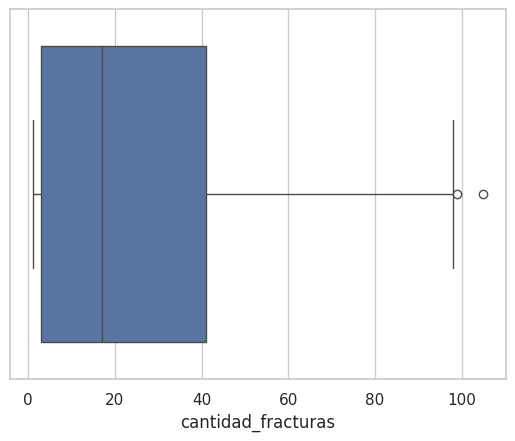

In [627]:
sns.boxplot(data=df , x='cantidad_fracturas')

En la cantidad de fracturas hay 2 valores atípicos que revisamos para ver si son útiles o no:

In [678]:
outliers_fracturas_indices = df['cantidad_fracturas'].nlargest(2).index
df.loc[outliers_fracturas_indices]

,_id,id_base_fractura_adjiv,idpozo,sigla,cuenca,areapermisoconcesion,yacimiento,formacion_productiva,tipo_reservorio,subtipo_reservorio,longitud_rama_horizontal_m,cantidad_fracturas,tipo_terminacion,arena_bombeada_nacional_tn,arena_bombeada_importada_tn,agua_inyectada_m3,co2_inyectado_m3,presion_maxima_psi,potencia_equipos_fractura_hp,fecha_inicio_fractura,fecha_fin_fractura,fecha_data,anio_if,mes_if,anio_ff,mes_ff,anio_carga,mes_carga,empresa_informante,mes,anio
4704,4705,5484,166964,VIS.Nq.BPO-2364(h),NEUQUINA,BAJADA DEL PALO OESTE,BAJADA DEL PALO OESTE,vaca muerta,NO CONVENCIONAL,SHALE,2906.5,105,Tapón disparo,12378.3600,0.0,93526.00,0.0,11960.000000,13713.9,2025-11-30T00:00:00,2025-12-29T00:00:00,2026-06-03T15:55:28,2025,11,2025,12,2026,6,VISTA ENERGY ARGENTINA SAU,11,2025
4280,4281,5034,166825,YPF.Nq.LLL-1861(h),NEUQUINA,LOMA CAMPANA,LOMA CAMPANA-LLL,vaca muerta,NO CONVENCIONAL,SHALE,4965.0,99,Tapón disparo,18803.4606,0.0,159319.63,0.0,11686.183322,44000.0,2025-05-08T00:00:00,2025-07-20T00:00:00,2025-10-14T15:44:24,2025,5,2025,7,2025,10,YPF S.A.,5,2025


*Nota sobre cantidad de fracturas:* los dos valores altos (99 y 105 etapas) son pozos shale de Vaca Muerta con mucha arena bombeada.

- El primero tiene una rama muy larga (4.965 m, unos 50 m por etapa): es consistente con un pozo real de alta intensidad.
- El segundo tiene una rama normal (2.906 m) con etapas muy juntas (unos 28 m por etapa, contra unos 63 m típicos). Es posible con diseños de espaciado reducido, pero también podría ser un error en la cantidad de etapas.

Se conservan los dos, y el segundo queda señalado para revisar.

<Axes: xlabel='arena_bombeada_nacional_tn'>

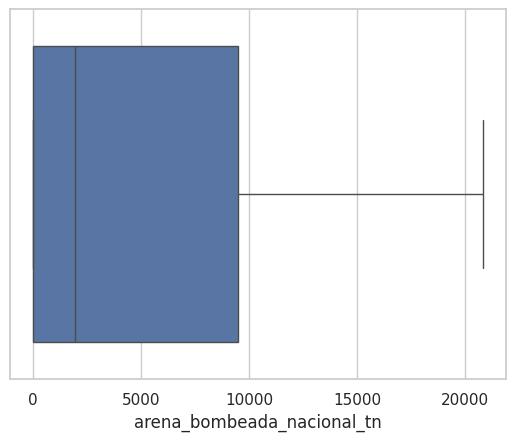

In [629]:
sns.boxplot(data=df , x='arena_bombeada_nacional_tn')

<Axes: xlabel='arena_bombeada_importada_tn'>

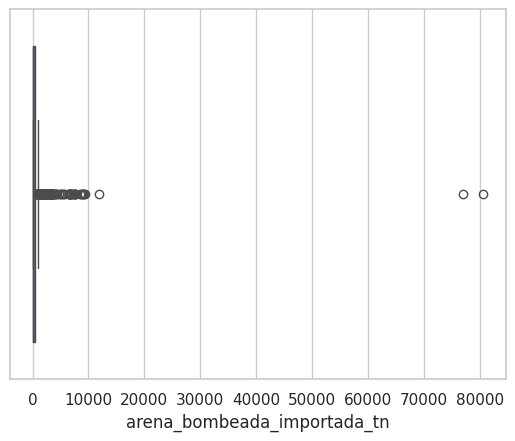

In [630]:
sns.boxplot(data=df , x='arena_bombeada_importada_tn')

Aparecen dos atípicos extremos. Además, muchos registros tienen 0 toneladas de arena importada (ver el conteo siguiente): esos ceros son válidos (se usó sólo arena nacional), así que no se eliminan del dataset, pero los excluimos para ver la distribución.

In [631]:
arena_importada_mayor_cero = df['arena_bombeada_importada_tn'] > 0
arena_importada_mayor_cero.value_counts()

,count
arena_bombeada_importada_tn,
True,2542
False,2348


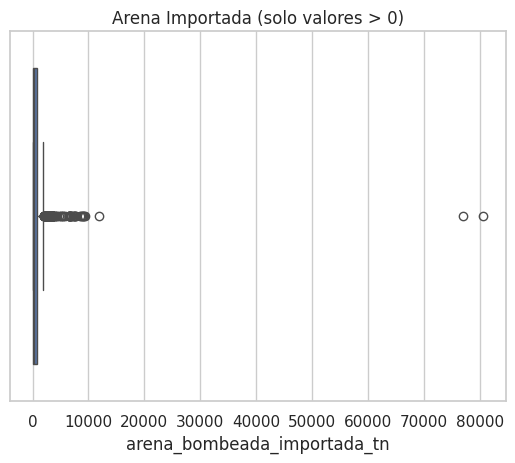

In [632]:
sns.boxplot(data=df[arena_importada_mayor_cero] , x='arena_bombeada_importada_tn')
plt.title('Arena Importada (solo valores > 0)')
plt.show()

In [633]:
arena_importada_mayores = df['arena_bombeada_importada_tn'].nlargest(3)
print(f"Relación entre el 2do mayor valor y el 3ro: {arena_importada_mayores.iloc[1] / arena_importada_mayores.iloc[2]:.1f} veces")

df.nlargest(5, 'arena_bombeada_importada_tn')[
    ['sigla', 'cantidad_fracturas', 'longitud_rama_horizontal_m',
     'arena_bombeada_nacional_tn', 'arena_bombeada_importada_tn', 'agua_inyectada_m3','co2_inyectado_m3','tipo_reservorio']
]

Relación entre el 2do mayor valor y el 3ro: 6.5 veces


,sigla,cantidad_fracturas,longitud_rama_horizontal_m,arena_bombeada_nacional_tn,arena_bombeada_importada_tn,agua_inyectada_m3,co2_inyectado_m3,tipo_reservorio
4671,PLU.Nq.LJE-1021(h),35,2674.0,10442.00,80652.00,0.0,0.0,NO CONVENCIONAL
4672,PLU.Nq.LJE.x-1022(h),40,2244.0,9863.00,77056.00,0.0,0.0,NO CONVENCIONAL
2214,XOM.Nq.PdY-1003(h),54,3387.0,12160.45,11839.64,537184.6,0.0,NO CONVENCIONAL
2393,YPF.Nq.LACh-95(h),36,1641.0,2062.00,9398.00,54348.0,0.0,NO CONVENCIONAL
2213,XOM.Nq.PdY-1002(h),52,3295.0,9601.18,9276.51,537184.6,0.0,NO CONVENCIONAL


Las dos filas con más arena importada (80.652 y 77.056 tn, más de 6 veces el siguiente valor de 11.840 tn) no tienen agua ni CO2 informados. Antes de usar la falta de agua como criterio, revisamos cuántas filas están en esa situación:

In [634]:
arena_total_eda = df['arena_bombeada_nacional_tn'] + df['arena_bombeada_importada_tn']
arena_sin_fluido = (arena_total_eda > 0) & (df['agua_inyectada_m3'] == 0) & (df['co2_inyectado_m3'] == 0)
print(f"Filas con arena bombeada pero sin agua ni CO2: {arena_sin_fluido.sum()}")
df.loc[arena_sin_fluido, 'empresa_informante'].value_counts()

Filas con arena bombeada pero sin agua ni CO2: 235


,count
empresa_informante,
TECPETROL S.A.,232
GEOPARK ARGENTINA S.A.,2
TOTAL AUSTRAL S.A.,1


Son 235 filas, 232 de ellas de Tecpetrol: es una forma de reportar de esa empresa (agua no informada), no un error aislado. Por eso las dos filas de GeoPark se eliminan por su volumen de arena fuera de escala, y en el resto el agua en 0 se trata como dato no informado (Paso 2.5).

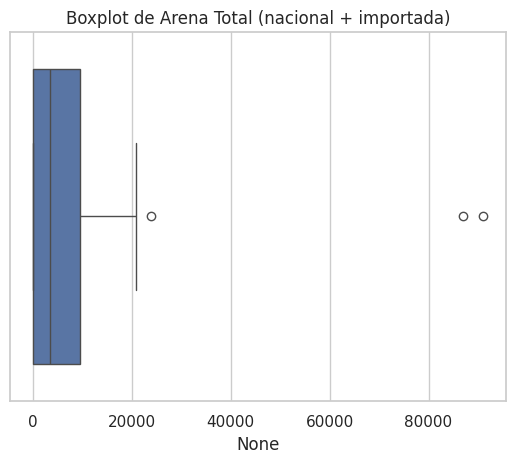

In [635]:
arena_total = df['arena_bombeada_importada_tn'] + df['arena_bombeada_nacional_tn']
sns.boxplot(x=arena_total)
plt.title('Boxplot de Arena Total (nacional + importada)')
plt.show()

In [636]:
# Confirmamos los atípicos de arena total con el criterio IQR
Q1_at = arena_total.quantile(0.25)
Q3_at = arena_total.quantile(0.75)
limite_superior_at = Q3_at + 1.5 * (Q3_at - Q1_at)
print(f"Límite superior: {limite_superior_at:.0f} t | Atípicos: {(arena_total > limite_superior_at).sum()}")
arena_total.nlargest(4)

Límite superior: 23574 t | Atípicos: 3


,0
4671,91094.00
4672,86919.00
2214,24000.09
4658,20834.00


El criterio IQR marca 3 atípicos. Los dos mayores son las filas de GeoPark que vamos a eliminar según lo anterior. El tercero (24.000 t) es el pozo con la 3ra mayor cantidad de arena importada: presenta un valor alto, pero puede ser real, ya que el resto de sus datos son coherentes.

<Axes: xlabel='co2_inyectado_m3'>

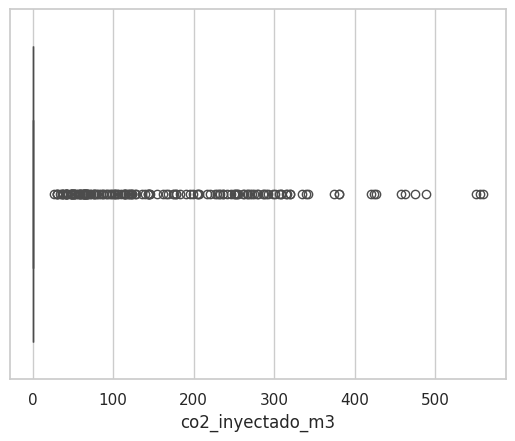

In [637]:
sns.boxplot(data=df , x='co2_inyectado_m3')

Como no es necesario que haya CO2, hay muchos valores de 0, por lo que la mediana queda muy corrida a la izquierda y las fracturas que usaron CO2 quedan como atípicas. Veamos cuántas fracturas usaron CO2 y si sus valores son atípicos:

In [638]:
CO2_mayor = df['co2_inyectado_m3']>0
CO2_mayor.value_counts()

,count
co2_inyectado_m3,
False,4731
True,159


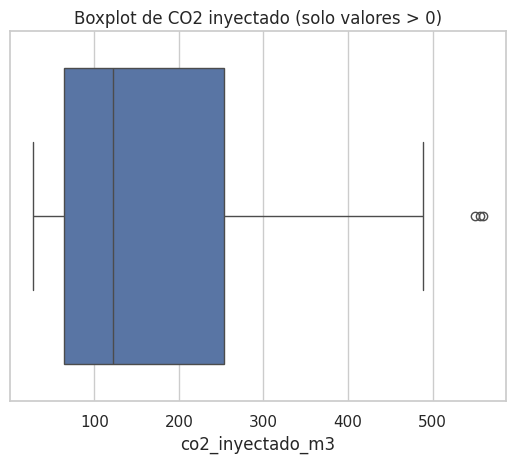

In [639]:
CO2_mayor = df['co2_inyectado_m3'] > 0
sns.boxplot(data=df[CO2_mayor] , x='co2_inyectado_m3')
plt.title('Boxplot de CO2 inyectado (solo valores > 0)')
plt.show()

In [640]:
# Confirmamos los atípicos de CO2 (sólo valores > 0) con el criterio IQR
co2_positivo = df.loc[CO2_mayor, 'co2_inyectado_m3']
Q1_co2 = co2_positivo.quantile(0.25)
Q3_co2 = co2_positivo.quantile(0.75)
limite_superior_co2 = Q3_co2 + 1.5 * (Q3_co2 - Q1_co2)
print(f"Límite superior: {limite_superior_co2:.0f} m3 | Atípicos: {(co2_positivo > limite_superior_co2).sum()}")
co2_positivo[co2_positivo > limite_superior_co2].sort_values()

Límite superior: 537 m3 | Atípicos: 3


,co2_inyectado_m3
2764,550.15
2604,556.00
2991,560.00


Hay 3 datos atípicos de CO2 (entre 550 y 560 m³), apenas por encima del límite superior. Revisamos las fracturas con más CO2:

In [641]:
df.nlargest(15, 'co2_inyectado_m3')[
    ['sigla', 'cantidad_fracturas', 'longitud_rama_horizontal_m',
     'arena_bombeada_nacional_tn', 'arena_bombeada_importada_tn', 'agua_inyectada_m3','co2_inyectado_m3','tipo_reservorio']
]

,sigla,cantidad_fracturas,longitud_rama_horizontal_m,arena_bombeada_nacional_tn,arena_bombeada_importada_tn,agua_inyectada_m3,co2_inyectado_m3,tipo_reservorio
2991,APS.RN.PZ-2003,5,0.0,0.0,4319.0,725.0,560.00,CONVENCIONAL
2604,APS.Nq.Sa.a-1252,6,0.0,0.0,212.0,645.0,556.00,NO CONVENCIONAL
2764,APS.RN.PZ.x-2001,4,0.0,0.0,203.0,651.2,550.15,CONVENCIONAL
2326,APS.Nq.Sa-1265(d),7,0.0,0.0,241.0,705.0,489.00,NO CONVENCIONAL
2308,APS.Nq.ADC-1026,1,0.0,0.0,143.0,300.0,475.00,NO CONVENCIONAL
835,APS.Nq.Sa-1234(d),6,0.0,0.0,139.0,558.0,462.00,NO CONVENCIONAL
801,APS.Nq.Sa-1217,6,0.0,0.0,174.0,543.9,458.00,NO CONVENCIONAL
2325,APS.Nq.Sa-1264(d),6,0.0,0.0,199.0,716.0,427.00,NO CONVENCIONAL
2320,APS.Nq.Sa-1234(d),6,0.0,0.0,183.0,555.0,424.00,NO CONVENCIONAL
825,APS.Nq.Sa-1238,5,0.0,0.0,184.0,396.4,420.00,NO CONVENCIONAL


No hay problema con los datos de CO2 atípicos: están apenas por encima del límite, el resto de sus datos es coherente y son valores posibles.

#### Agua inyectada
Es una variable central de la fractura hidráulica, así que la revisamos igual que las demás:

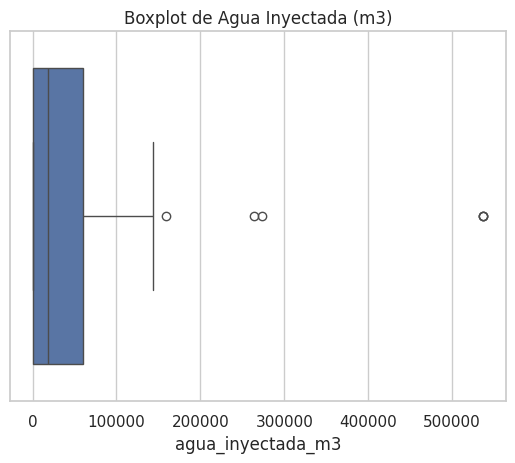

Filas con agua inyectada = 0: 305
Valores de agua que se repiten en más de un registro: 175 (506 filas)


,sigla,empresa_informante,agua_inyectada_m3
2212,XOM.Nq.PdY-1001(h),EXXONMOBIL EXPLORATION ARGENTINA S.R.L.,537184.6
2213,XOM.Nq.PdY-1002(h),EXXONMOBIL EXPLORATION ARGENTINA S.R.L.,537184.6
2214,XOM.Nq.PdY-1003(h),EXXONMOBIL EXPLORATION ARGENTINA S.R.L.,537184.6


In [642]:
sns.boxplot(data=df, x='agua_inyectada_m3')
plt.title('Boxplot de Agua Inyectada (m3)')
plt.show()

print(f"Filas con agua inyectada = 0: {(df['agua_inyectada_m3'] == 0).sum()}")

# Valores de agua idénticos en más de un registro
repeticiones_agua = df.loc[df['agua_inyectada_m3'] > 0, 'agua_inyectada_m3'].value_counts()
agua_repetida = repeticiones_agua[repeticiones_agua >= 2]
print(f"Valores de agua que se repiten en más de un registro: {len(agua_repetida)} ({agua_repetida.sum()} filas)")
df.loc[df['agua_inyectada_m3'] == agua_repetida.index.max(), ['sigla', 'empresa_informante', 'agua_inyectada_m3']]

Hay valores de agua idénticos en varios pozos (por ejemplo, 537.184,6 m³ en tres pozos de ExxonMobil, que además es el máximo del dataset). Probablemente es el total de un pad (varios pozos fracturados juntos) repetido en cada pozo. Sin más información no se puede repartir, así que se deja como está y se tiene en cuenta al interpretar sumas y promedios de agua.

<Axes: xlabel='presion_maxima_psi'>

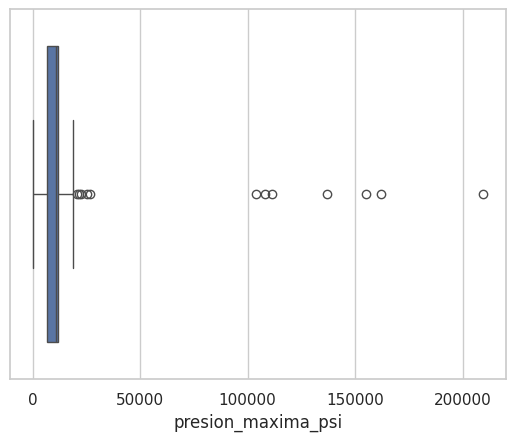

In [643]:
sns.boxplot(data=df , x='presion_maxima_psi')

Hay muchos valores cercanos a 0 y un grupo de valores muy altos de entre 100.000 a 210.000 psi.

Según lo consultado con IA, más de 20.000 psi ya no es probable dentro de un pozo, y valores de cientos de miles de psi no son físicamente alcanzables con equipos de fractura estándar: son una señal fuerte de error de carga.

Por el otro lado, cada registro es una fractura realizada, y toda fractura necesita presión para abrir la roca: una presión menor a 1.000 psi es un dato faltante mal cargado. Revisamos además si hay registros sin ningún insumo informado (ni arena, ni agua, ni CO2):

In [644]:
hubo_bombeo_eda = (
    df['arena_bombeada_nacional_tn'] + df['arena_bombeada_importada_tn']
    + df['agua_inyectada_m3'] + df['co2_inyectado_m3']
) > 0

presion_alta = df['presion_maxima_psi'] > 20000
presion_baja = df['presion_maxima_psi'] < 1000

print(f"Presión > 20.000 psi (fuera de rango): {presion_alta.sum()}")
print(f"Presión < 1.000 psi (dato faltante): {presion_baja.sum()}")
print(f"   de ellas con presión exactamente 0: {(presion_baja & (df['presion_maxima_psi'] == 0)).sum()}")

sin_insumos_eda = df[~hubo_bombeo_eda]
print(f"\nRegistros sin ningún insumo informado (arena, agua y CO2 en 0): {len(sin_insumos_eda)}")
print(f"   con presión >= 1.000 psi informada: {(sin_insumos_eda['presion_maxima_psi'] >= 1000).sum()}")
print(f"   con potencia >= 1 HP informada: {(sin_insumos_eda['potencia_equipos_fractura_hp'] >= 1).sum()}")
sin_insumos_eda['empresa_informante'].value_counts()

Presión > 20.000 psi (fuera de rango): 12
Presión < 1.000 psi (dato faltante): 86
   de ellas con presión exactamente 0: 78

Registros sin ningún insumo informado (arena, agua y CO2 en 0): 70
   con presión >= 1.000 psi informada: 33
   con potencia >= 1 HP informada: 39


,count
empresa_informante,
TECPETROL S.A.,70


Los 70 registros sin ningún insumo son todos de Tecpetrol, y muchos tienen presión o potencia informadas: son fracturas reales en las que la empresa no declaró los insumos (el mismo patrón que el agua no informada del Paso 1.8). Por eso, en esos registros, una presión o potencia en 0 tampoco es coherente: es un faltante más.

Hipótesis: los valores de más de 100.000 podrían estar cargados en kPa en lugar de psi (1 psi = 6,89476 kPa). Veamos a cuánto equivaldrían:

In [645]:
presiones_altas = df.loc[presion_alta, ['sigla', 'tipo_reservorio', 'presion_maxima_psi']].copy()
presiones_altas['si_fuera_kPa_en_psi'] = (presiones_altas['presion_maxima_psi'] / 6.89476).round(0)

mayores_a_100000 = presiones_altas['presion_maxima_psi'] > 100000
plausibles_en_kpa = mayores_a_100000 & (presiones_altas['si_fuera_kPa_en_psi'] <= 20000)
print(f"Presiones mayores a 100.000: {mayores_a_100000.sum()} | Quedarían en rango (<= 20.000 psi) si fueran kPa: {plausibles_en_kpa.sum()}")

presiones_altas.sort_values('presion_maxima_psi')

Presiones mayores a 100.000: 7 | Quedarían en rango (<= 20.000 psi) si fueran kPa: 4


,sigla,tipo_reservorio,presion_maxima_psi,si_fuera_kPa_en_psi
2703,XOM.Nq.BdC-13(h),NO CONVENCIONAL,20473.000000,2969.0
3016,YPF.Nq.RN-2070(d),NO CONVENCIONAL,21820.013050,3165.0
1782,TPT.Nq.PS-1006,CONVENCIONAL,22444.000000,3255.0
4085,YPF.Nq.RN-2215(d),NO CONVENCIONAL,25455.000000,3692.0
4084,YPF.Nq.RN-2214(d),NO CONVENCIONAL,26775.000000,3883.0
3858,VIS.Nq.BPE-2023(h),NO CONVENCIONAL,104089.000000,15097.0
4789,TAU.Nq.AP-1116(h),NO CONVENCIONAL,107903.000000,15650.0
4397,TPT.Nq.FP-1342(h),NO CONVENCIONAL,111515.000000,16174.0
4680,YPF.Nq.LajE-56(h),NO CONVENCIONAL,136958.137203,19864.0
4681,YPF.Nq.LajE-57(h),NO CONVENCIONAL,154807.010711,22453.0


Sólo 4 de los 7 valores mayores a 100.000 quedarían en un rango plausible si fueran kPa; los demás siguen fuera de rango. Como no se puede confirmar la unidad, los 12 valores mayores a 20.000 psi se tratan como faltantes. Además, la presión y la potencia típicas dependen mucho del tipo de reservorio:

In [646]:
df.groupby('tipo_reservorio')[['presion_maxima_psi', 'potencia_equipos_fractura_hp']].median()

,presion_maxima_psi,potencia_equipos_fractura_hp
tipo_reservorio,,
CONVENCIONAL,5592.00,554.5
NO CONVENCIONAL,11371.87,24794.5
NO DISCRIMINADO,12899.00,27293.6


Un pozo convencional usa unos 550 HP y uno no convencional unos 25.000 HP: imputar con la mediana global distorsionaría los convencionales. Por eso en la transformación imputamos con la mediana de cada tipo y subtipo de reservorio.

<Axes: xlabel='potencia_equipos_fractura_hp'>

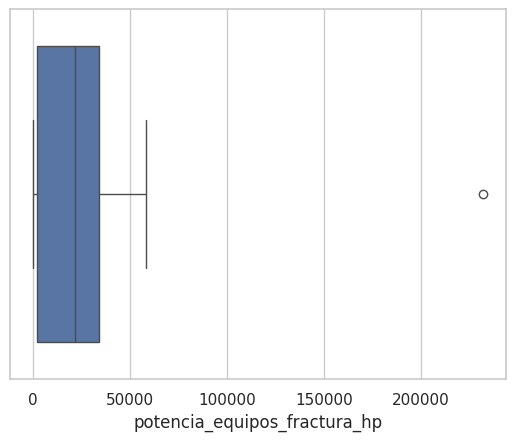

In [647]:
sns.boxplot(data=df , x='potencia_equipos_fractura_hp')

En el boxplot se ve un solo dato desviado; lo confirmamos con el criterio IQR y revisamos también los faltantes y las potencias nulas:

In [648]:
potencia = df['potencia_equipos_fractura_hp']
Q1_pot = potencia.quantile(0.25)
Q3_pot = potencia.quantile(0.75)
limite_superior_pot = Q3_pot + 1.5 * (Q3_pot - Q1_pot)
print(f"Atípicos por criterio IQR (> {limite_superior_pot:.0f} HP): {(potencia > limite_superior_pot).sum()}")

print(f"Potencia NaN (faltante): {potencia.isna().sum()}")
print(f"Potencia < 1 HP (dato faltante): {(potencia < 1).sum()}")
print(f"Potencia > 65.000 HP (fuera de rango): {(potencia > 65000).sum()}")

Atípicos por criterio IQR (> 81684 HP): 1
Potencia NaN (faltante): 51
Potencia < 1 HP (dato faltante): 163
Potencia > 65.000 HP (fuera de rango): 1


In [649]:

df.nlargest(5, 'potencia_equipos_fractura_hp')[
    ['sigla', 'cantidad_fracturas', 'longitud_rama_horizontal_m', 'presion_maxima_psi', 'potencia_equipos_fractura_hp']
]

,sigla,cantidad_fracturas,longitud_rama_horizontal_m,presion_maxima_psi,potencia_equipos_fractura_hp
3858,VIS.Nq.BPE-2023(h),53,3125.00,104089.00,232159.2892
4705,VIS.Nq.AF-1401(h),63,3585.00,12787.00,58161.0000
4707,VIS.Nq.AF-1403(h),59,3399.00,12229.00,56800.0000
4646,PCN.Nq.BdC-1007(h),60,3150.89,11527.81,54963.0000
4706,VIS.Nq.AF-1402(h),63,3608.00,11932.00,52399.0000


El valor más alto (232.159 HP) pertenece a una fila cuya presión máxima (104.089 psi) también está fuera de rango: es un error de carga. Se trata como faltante y se imputa igual que la presión.

In [650]:
zero_counts = (df['longitud_rama_horizontal_m']==0).value_counts()
print(f"Cantidad de pozos con longitud_rama_horizontal_m igual a 0: {zero_counts.get(True, 0)}")
display(zero_counts)

Cantidad de pozos con longitud_rama_horizontal_m igual a 0: 2054


,count
longitud_rama_horizontal_m,
False,2836
True,2054


In [651]:
ceros_rama = df[df['longitud_rama_horizontal_m'] == 0]
es_horizontal_eda = df['sigla'].str.contains(r'\(h\)', na=False)

# ¿Cuántos de esos pozos con rama = 0 están marcados como horizontales "(h)" en la sigla?
print(ceros_rama['sigla'].str.contains(r'\(h\)').value_counts())
rama_corta = es_horizontal_eda & (df['longitud_rama_horizontal_m'] > 0) & (df['longitud_rama_horizontal_m'] < 50)
print(f"\nPozos (h) con rama entre 0 y 50 m: {rama_corta.sum()}")
print(f"Pozos sin (h) con rama > 0: {(~es_horizontal_eda & (df['longitud_rama_horizontal_m'] > 0)).sum()}")

sigla
False    2005
True       49
Name: count, dtype: int64

Pozos (h) con rama entre 0 y 50 m: 18
Pozos sin (h) con rama > 0: 212


Hay 49 pozos horizontales con 0 metros de rama y 18 con menos de 50 m: son datos faltantes (67 en total). Los ceros de los pozos que no son horizontales son correctos ("no aplica").

Hay además 212 pozos sin "(h)" en la sigla que tienen rama mayor a 0; no se modifican, pero quedan para revisar.

## Parte 2: Transformación y Limpieza de Datos

Establecemos una copia de seguridad `df_copia` para realizar todas las operaciones de curación de datos sin alterar la fuente original. Cada paso queda anotado en `registro_cambios` con la cantidad de filas afectadas y el criterio aplicado.

In [652]:
df_copia = df.copy()

# Registro de cada transformación: paso, filas afectadas y criterio
registro_cambios = []

def registrar(paso, filas, criterio):
    registro_cambios.append({'paso': paso, 'filas_afectadas': int(filas), 'criterio': criterio})

### Paso 2.1: Conversión y Tipado de Fechas
Transformamos las columnas de fechas de formato de texto (`object`) a formato temporal de Pandas (`datetime`).

In [653]:
df_copia["fecha_inicio_fractura"] = pd.to_datetime(df["fecha_inicio_fractura"], format="mixed")
df_copia["fecha_fin_fractura"] = pd.to_datetime(df["fecha_fin_fractura"], format="mixed")
df_copia["fecha_data"] = pd.to_datetime(df["fecha_data"], format="mixed")

### Paso 2.2: Normalización de Variables Categóricas
Pasamos todos los registros de texto a minúsculas y removemos los espacios sobrantes (al inicio, al final y dobles) para asegurar consistencia

In [654]:
columnas_texto = ['cuenca', 'areapermisoconcesion', 'yacimiento', 'formacion_productiva',
                  'tipo_reservorio', 'subtipo_reservorio', 'tipo_terminacion', 'empresa_informante']

for columna in columnas_texto:
    df_copia[columna] = (
        df_copia[columna]
        .str.strip()
        .str.lower()
        .str.replace(r'\s+', ' ', regex=True)
    )

print(f"Áreas de concesión distintas: antes {df['areapermisoconcesion'].nunique()} | después {df_copia['areapermisoconcesion'].nunique()}")
df_copia['formacion_productiva'].unique()

Áreas de concesión distintas: antes 106 | después 106


array(['los molles', 'vaca muerta', 'magallanes', 'springhill', 'anita',
       'agrio', 'huitrín', 'rayoso', 'formación improductiva', 'lajas',
       'precuyo', 'lotena', 'mulichinco', 'punta rosada', 'grupo neuquén',
       'chachao', 'mina el carmen', 'comodoro rivadavia', 'loma montosa',
       'el trebol', 'sierras blancas', 'quintuco', 'tordillo',
       'palermo aike', 'cañadon seco', 'pozo d-129', 'bajo barreal',
       'castillo'], dtype=object)

### Paso 2.3: Imputación de Tipo y Subtipo de Reservorio
Imputamos con el valor más frecuente de la misma cuenca y formación, y si esa formación no tiene referencia, con el de la misma cuenca. "No discriminado" significa que no se sabe, así que lo tratamos igual que un NaN.

In [655]:
def moda_o_nan(serie):
    moda = serie.mode()
    return moda.iloc[0] if not moda.empty else np.nan

df_copia['tipo_reservorio'] = df_copia['tipo_reservorio'].replace({'no discriminado': np.nan})
tipo_faltante = df_copia['tipo_reservorio'].isna()

moda_por_formacion = df_copia.groupby(['cuenca', 'formacion_productiva'])['tipo_reservorio'].transform(moda_o_nan)
moda_por_cuenca = df_copia.groupby('cuenca')['tipo_reservorio'].transform(moda_o_nan)
df_copia['tipo_reservorio'] = df_copia['tipo_reservorio'].fillna(moda_por_formacion).fillna(moda_por_cuenca)

registrar('2.3 Tipo de reservorio', tipo_faltante.sum(), 'NaN / no discriminado -> moda de su cuenca y formación')
df_copia.loc[tipo_faltante].groupby(['cuenca', 'formacion_productiva', 'tipo_reservorio']).size()

cuenca           formacion_productiva    tipo_reservorio
austral          springhill              no convencional    4
golfo san jorge  castillo                convencional       8
                 cañadon seco            convencional       2
                 comodoro rivadavia      convencional       4
                 mina el carmen          convencional       4
neuquina         agrio                   no convencional    1
                 formación improductiva  convencional       1
                 huitrín                 convencional       4
                 precuyo                 no convencional    7
                 vaca muerta             no convencional    1
dtype: int64

Dos casos quedan con poca evidencia y conviene revisarlos:

- springhill (4 registros → no convencional): en el dataset sólo hay 3 registros de referencia de esa formación (1 convencional y 2 no convencionales, ver Paso 1.4). Además, Springhill es tradicionalmente el reservorio convencional de la cuenca Austral, por lo que el resultado es dudoso.
- formación improductiva (1 registro → convencional): hay un empate 2 a 2 entre convencional y no convencional, que `mode()` resuelve por orden alfabético.

In [656]:
subtipo_faltante = df_copia['subtipo_reservorio'].isna()
es_convencional = df_copia['tipo_reservorio'] == 'convencional'

# Los reservorios convencionales no tienen subtipo
df_copia.loc[subtipo_faltante & es_convencional, 'subtipo_reservorio'] = 'no corresponde'

# Los no convencionales toman el subtipo más frecuente de los no convencionales de su cuenca y formación
subtipo_no_convencional = df_copia['subtipo_reservorio'].where(~es_convencional)
moda_subtipo_formacion = subtipo_no_convencional.groupby(
    [df_copia['cuenca'], df_copia['formacion_productiva']]).transform(moda_o_nan)
moda_subtipo_cuenca = subtipo_no_convencional.groupby(df_copia['cuenca']).transform(moda_o_nan)

faltante_no_convencional = subtipo_faltante & ~es_convencional
df_copia.loc[faltante_no_convencional, 'subtipo_reservorio'] = (
    moda_subtipo_formacion[faltante_no_convencional].fillna(moda_subtipo_cuenca[faltante_no_convencional])
)

registrar('2.3 Subtipo de reservorio', (subtipo_faltante & es_convencional).sum(), 'Convencional sin subtipo -> "no corresponde"')
registrar('2.3 Subtipo de reservorio', faltante_no_convencional.sum(), 'No convencional sin subtipo -> moda de su cuenca y formación')

# Control: ningún convencional puede quedar como shale o tight
pd.crosstab(df_copia['tipo_reservorio'], df_copia['subtipo_reservorio'])

subtipo_reservorio,no corresponde,shale,tight
tipo_reservorio,,,
convencional,956,0,0
no convencional,0,3017,917


Comparamos la distribución de tipo y subtipo de reservorio antes y después de la imputación:

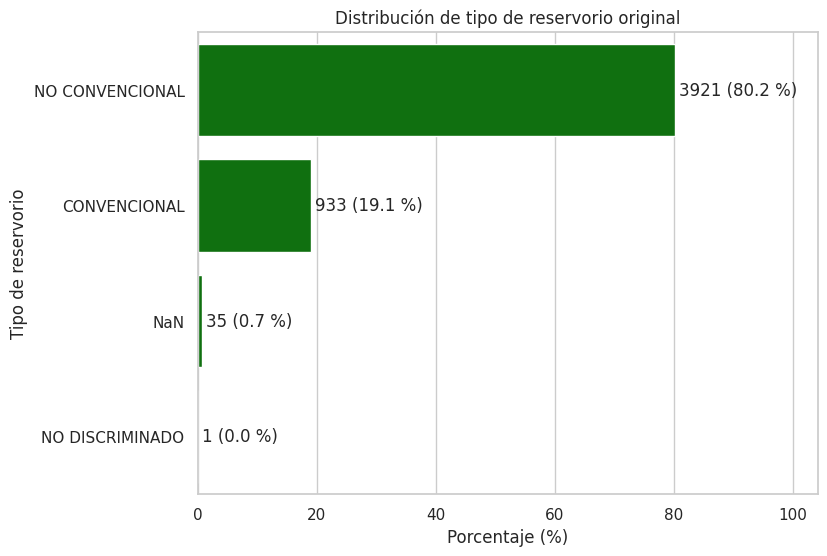

In [657]:
tipo_original_conteo = df['tipo_reservorio'].fillna('NaN').value_counts()
tipo_original = tipo_original_conteo / tipo_original_conteo.sum() * 100

plt.figure(figsize=(8,6))
ax = sns.barplot(x=tipo_original.values, y=tipo_original.index, order=tipo_original.index, color='green')
# Etiqueta de cada barra: cantidad de registros y porcentaje
ax.bar_label(ax.containers[0], labels=[f'{n} ({p:.1f} %)' for n, p in zip(tipo_original_conteo, tipo_original)], padding=3)
plt.xlim(0, tipo_original.max() * 1.3)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Tipo de reservorio')
plt.title('Distribución de tipo de reservorio original')
plt.show()

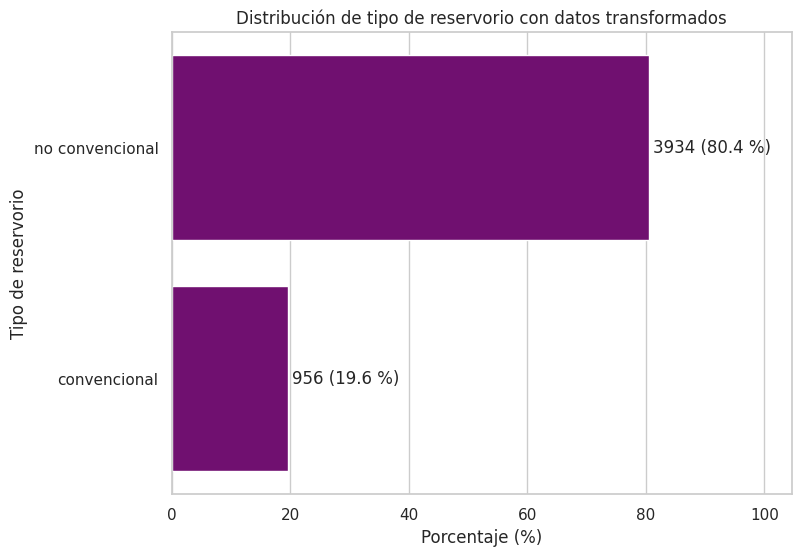

In [658]:
tipo_transformado_conteo = df_copia['tipo_reservorio'].value_counts()
tipo_transformado = tipo_transformado_conteo / tipo_transformado_conteo.sum() * 100

plt.figure(figsize=(8,6))
ax = sns.barplot(x=tipo_transformado.values, y=tipo_transformado.index, order=tipo_transformado.index, color='purple')
# Etiqueta de cada barra: cantidad de registros y porcentaje
ax.bar_label(ax.containers[0], labels=[f'{n} ({p:.1f} %)' for n, p in zip(tipo_transformado_conteo, tipo_transformado)], padding=3)
plt.xlim(0, tipo_transformado.max() * 1.3)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Tipo de reservorio')
plt.title('Distribución de tipo de reservorio con datos transformados')
plt.show()

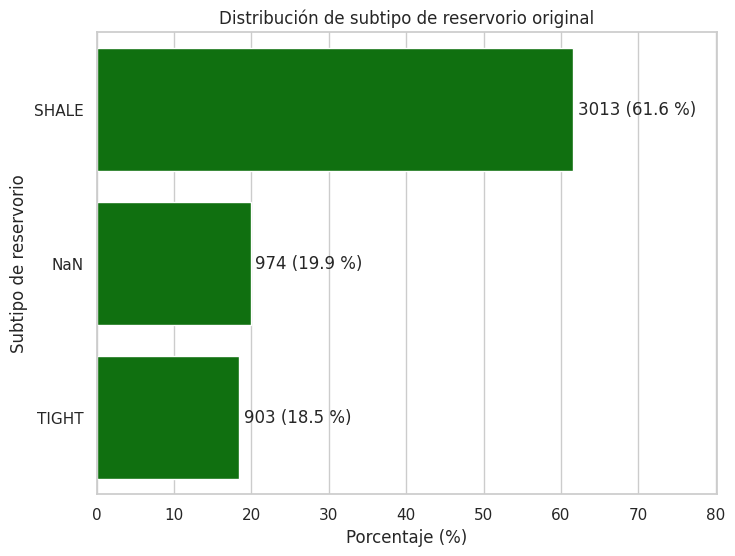

In [659]:
subtipo_original_conteo = df['subtipo_reservorio'].fillna('NaN').value_counts()
subtipo_original = subtipo_original_conteo / subtipo_original_conteo.sum() * 100

plt.figure(figsize=(8,6))
ax = sns.barplot(x=subtipo_original.values, y=subtipo_original.index, order=subtipo_original.index, color='green')
# Etiqueta de cada barra: cantidad de registros y porcentaje
ax.bar_label(ax.containers[0], labels=[f'{n} ({p:.1f} %)' for n, p in zip(subtipo_original_conteo, subtipo_original)], padding=3)
plt.xlim(0, subtipo_original.max() * 1.3)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Subtipo de reservorio')
plt.title('Distribución de subtipo de reservorio original')
plt.show()

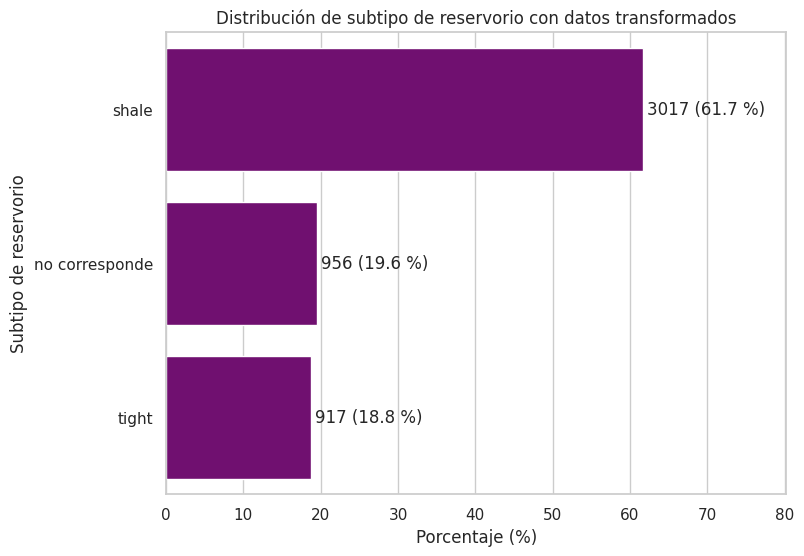

In [660]:
subtipo_transformado_conteo = df_copia['subtipo_reservorio'].value_counts()
subtipo_transformado = subtipo_transformado_conteo / subtipo_transformado_conteo.sum() * 100

plt.figure(figsize=(8,6))
ax = sns.barplot(x=subtipo_transformado.values, y=subtipo_transformado.index, order=subtipo_transformado.index, color='purple')
# Etiqueta de cada barra: cantidad de registros y porcentaje
ax.bar_label(ax.containers[0], labels=[f'{n} ({p:.1f} %)' for n, p in zip(subtipo_transformado_conteo, subtipo_transformado)], padding=3)
plt.xlim(0, subtipo_transformado.max() * 1.3)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Subtipo de reservorio')
plt.title('Distribución de subtipo de reservorio con datos transformados')
plt.show()

### Paso 2.4: Unificación de Nombres de Empresas
Unificamos razones sociales y firmas comerciales para evitar duplicidad de categorías.

In [661]:
empresa_renombrada = df_copia['empresa_informante'] == 'vista energy argentina sau'
df_copia['empresa_informante'] = df_copia['empresa_informante'].replace({
    'vista energy argentina sau': 'vista oil & gas argentina sau'
})
registrar('2.4 Empresas', empresa_renombrada.sum(), 'vista energy -> vista oil & gas (cambio de nombre)')

display(df_copia['empresa_informante'].unique())

array(['capex s.a.', 'ypf s.a.', 'compañía general de combustibles s.a.',
       'shell argentina s.a.', 'pluspetrol s.a.',
       'chevron argentina s.r.l.', 'vista oil & gas argentina sau',
       'pan american energy sl', 'wintershall dea argentina s.a',
       'exxonmobil exploration argentina s.r.l.',
       'petrolera el trebol s.a.', 'tecpetrol s.a.', 'medanito s.a.',
       'oilstone energia s.a.', 'pampa energia s.a.',
       'total austral s.a.', 'compañías asociadas petroleras s.a.',
       'sinopec argentina exploration and production, inc.',
       'cgc energia sau', 'geopark argentina s.a.',
       'pluspetrol cuenca neuquina s.r.l.',
       'phoenix global resources s.a.'], dtype=object)

### Paso 2.5: Arena y Agua
Los dos valores altos de cantidad de fracturas se conservan (son pozos reales, ver Paso 1.8). Para la arena, eliminamos los registros con volúmenes de arena importada fuera de escala.

Para el agua: no hay fractura sin fluido, así que un registro con agua y CO2 en 0 significa que el agua no fue informada. Esto incluye los registros sin ningún insumo informado, que además quedan marcados.

In [662]:
# Establecemos el límite máximo razonable de arena importada:
# el siguiente valor más alto es de 11.840 tn
umbral_max_arena = 15000
filas_corruptas = df_copia['arena_bombeada_importada_tn'] > umbral_max_arena

print(f"Filas con arena importada fuera de escala: {filas_corruptas.sum()}")
display(df_copia.loc[filas_corruptas, ['sigla', 'arena_bombeada_importada_tn', 'agua_inyectada_m3', 'empresa_informante', 'anio_if']])

Filas con arena importada fuera de escala: 2


,sigla,arena_bombeada_importada_tn,agua_inyectada_m3,empresa_informante,anio_if
4671,PLU.Nq.LJE-1021(h),80652.0,0.0,geopark argentina s.a.,2022
4672,PLU.Nq.LJE.x-1022(h),77056.0,0.0,geopark argentina s.a.,2022


In [663]:
# Nos quedamos con las filas válidas, menores o iguales a 15000
dimensiones_antes = df_copia.shape[0]
df_copia = df_copia[~filas_corruptas].copy().reset_index(drop=True)
registrar('2.5 Arena', filas_corruptas.sum(), 'Arena importada > 15.000 tn (más de 6 veces el siguiente valor): se eliminan')

print(f"Dimensiones antes de este paso: {dimensiones_antes} filas")
print(f"Dimensiones post-limpieza: {df_copia.shape[0]} filas")

Dimensiones antes de este paso: 4890 filas
Dimensiones post-limpieza: 4888 filas


In [664]:
df_copia['arena_total_tn'] = df_copia['arena_bombeada_nacional_tn'] + df_copia['arena_bombeada_importada_tn']

# No hay fractura sin fluido: agua en 0 sin CO2 significa que el agua no fue informada
agua_no_informada = (df_copia['agua_inyectada_m3'] == 0) & (df_copia['co2_inyectado_m3'] == 0)
# Registros sin ningún insumo informado (ni arena, ni agua, ni CO2)
sin_insumos_informados = agua_no_informada & (df_copia['arena_total_tn'] == 0)

df_copia['agua_no_informada'] = agua_no_informada
df_copia['sin_insumos_informados'] = sin_insumos_informados
df_copia.loc[agua_no_informada, 'agua_inyectada_m3'] = np.nan
registrar('2.5 Agua', agua_no_informada.sum(), 'Agua = 0 y CO2 = 0 -> NaN (no informada: no hay fractura sin fluido)')

print(f"Registros con agua no informada: {agua_no_informada.sum()}")
print(f"   de ellos sin ningún insumo informado: {sin_insumos_informados.sum()}")

Registros con agua no informada: 303
   de ellos sin ningún insumo informado: 70


### Paso 2.6: Tratamiento de Presiones Imposibles ("presion_maxima_psi")
Tratamos como faltantes las presiones mayores a 20.000 psi y las menores a 1.000 psi (toda fractura necesita presión para abrir la roca). Las imputamos con la mediana de su tipo y subtipo de reservorio, calculada con las presiones válidas, y dejamos una columna que indica qué valores fueron imputados.

Presiones imputadas: 98 | Faltantes restantes: 0


tipo_reservorio  subtipo_reservorio
convencional     no corresponde         5900.000000
no convencional  shale                 11590.591344
                 tight                  5674.566900
Name: mediana_psi, dtype: float64

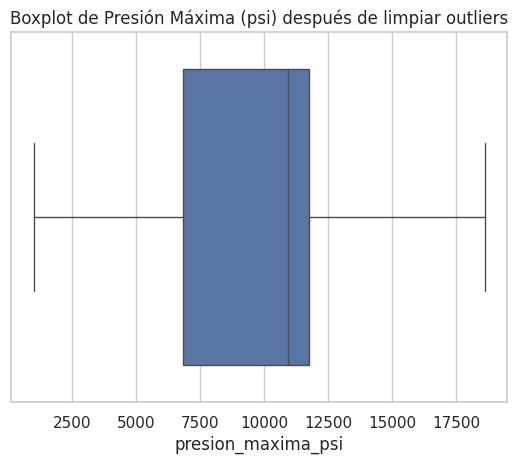

In [665]:
grupos_reservorio = ['tipo_reservorio', 'subtipo_reservorio']

presion = df_copia['presion_maxima_psi']
presion_invalida = (presion > 20000) | (presion < 1000)
df_copia['presion_imputada'] = presion_invalida
df_copia.loc[presion_invalida, 'presion_maxima_psi'] = np.nan

referencia_presion = df_copia['presion_maxima_psi']
mediana_presion = referencia_presion.groupby([df_copia[g] for g in grupos_reservorio]).transform('median')
df_copia['presion_maxima_psi'] = df_copia['presion_maxima_psi'].fillna(mediana_presion)

registrar('2.6 Presión', presion_invalida.sum(), '> 20.000 psi o < 1.000 psi -> mediana por tipo/subtipo')
print(f"Presiones imputadas: {presion_invalida.sum()} | Faltantes restantes: {df_copia['presion_maxima_psi'].isna().sum()}")
display(referencia_presion.groupby([df_copia[g] for g in grupos_reservorio]).median().rename('mediana_psi'))

sns.boxplot(data=df_copia, x='presion_maxima_psi')
plt.title('Boxplot de Presión Máxima (psi) después de limpiar outliers')
plt.show()

### Paso 2.7: Limpieza de Potencia de Equipos de Fractura (potencia_equipos_fractura_hp)
Tratamos como faltantes los NaN, las potencias menores a 1 HP (toda fractura necesita bombas) y las mayores a 65.000 HP, e imputamos con la mediana de su tipo y subtipo de reservorio.

In [666]:
potencia = df_copia['potencia_equipos_fractura_hp']
potencia_invalida = potencia.isna() | (potencia < 1) | (potencia > 65000)
df_copia['potencia_imputada'] = potencia_invalida

print(f"De los registros inválidos, {potencia.isna().sum()} eran NaN originales")
df_copia.loc[potencia_invalida, 'potencia_equipos_fractura_hp'] = np.nan

referencia_potencia = df_copia['potencia_equipos_fractura_hp']
mediana_potencia = referencia_potencia.groupby([df_copia[g] for g in grupos_reservorio]).transform('median')
df_copia['potencia_equipos_fractura_hp'] = df_copia['potencia_equipos_fractura_hp'].fillna(mediana_potencia)

registrar('2.7 Potencia', potencia_invalida.sum(), 'NaN, < 1 HP o > 65.000 HP -> mediana por tipo/subtipo')
print(f"Potencias imputadas: {potencia_invalida.sum()} | Faltantes restantes: {df_copia['potencia_equipos_fractura_hp'].isna().sum()}")
referencia_potencia.groupby([df_copia[g] for g in grupos_reservorio]).median().rename('mediana_hp')

De los registros inválidos, 51 eran NaN originales
Potencias imputadas: 215 | Faltantes restantes: 0


tipo_reservorio  subtipo_reservorio
convencional     no corresponde          746.0
no convencional  shale                 28000.0
                 tight                 16000.0
Name: mediana_hp, dtype: float64

### Paso 2.8: Corrección de Fechas Inconsistentes
Revisamos las fracturas con duración negativa (fechas invertidas) o mayor a un año. La duración típica de una fractura depende mucho del subtipo de reservorio (las medianas se calculan en la celda siguiente), así que tomamos la fecha de inicio como referencia y recalculamos la de fin sumándole la duración mediana de su subtipo, calculada sólo con las fracturas de fechas coherentes.

Excepción: si la fecha de inicio es posterior a la propia declaración (`fecha_data`), la fecha errónea es el inicio. En ese caso tomamos la fecha de fin como referencia y le restamos la mediana.

La duración de estos registros queda estimada: la columna `fecha_corregida` permite excluirlos de cualquier análisis de duración.

In [667]:
# 1. Calculamos las duraciones para los registros coherentes (duracion >= 0 y <= 365 días)
duracion_inicial = (df_copia['fecha_fin_fractura'] - df_copia['fecha_inicio_fractura']).dt.days
coherente_mask = (duracion_inicial >= 0) & (duracion_inicial <= 365)

# 2. Obtenemos la duración mediana de las fracturas según el subtipo de reservorio
medianas_por_subtipo = duracion_inicial[coherente_mask].groupby(df_copia['subtipo_reservorio']).median()
print("Mediana de duración de fractura por subtipo de reservorio (en días):")
display(medianas_por_subtipo)

# 3. Identificamos los registros con fechas anómalas (duración negativa o mayor a un año)
fechas_anomalas = (duracion_inicial < 0) | (duracion_inicial > 365)
print(f"\nRegistros con fechas anómalas identificados: {fechas_anomalas.sum()}")

Mediana de duración de fractura por subtipo de reservorio (en días):


,0
subtipo_reservorio,
no corresponde,1.0
shale,21.0
tight,4.0



Registros con fechas anómalas identificados: 62


In [668]:
# 4. Aplicamos la corrección por subtipo sobre los registros anómalos
df_copia['fecha_corregida'] = fechas_anomalas

# Duración mediana del subtipo de cada fila
dias_mediana = pd.to_timedelta(
    df_copia['subtipo_reservorio'].map(medianas_por_subtipo).round().astype(int), unit='D'
)

# Si el inicio es posterior a la declaración, la fecha errónea es el inicio:
# tomamos el fin como referencia y recalculamos el inicio
inicio_posterior_a_carga = fechas_anomalas & (df_copia['fecha_inicio_fractura'] > df_copia['fecha_data'])
corregir_fin = fechas_anomalas & ~inicio_posterior_a_carga

# En el resto, recalculamos la fecha de fin a partir de la de inicio + la duración mediana del subtipo
df_copia.loc[corregir_fin, 'fecha_fin_fractura'] = (
    df_copia.loc[corregir_fin, 'fecha_inicio_fractura'] + dias_mediana[corregir_fin]
)
df_copia.loc[inicio_posterior_a_carga, 'fecha_inicio_fractura'] = (
    df_copia.loc[inicio_posterior_a_carga, 'fecha_fin_fractura'] - dias_mediana[inicio_posterior_a_carga]
)

# 5. Actualizamos la duración corregida y las columnas de año/mes derivadas
df_copia['duracion_fractura_dias'] = (df_copia['fecha_fin_fractura'] - df_copia['fecha_inicio_fractura']).dt.days
df_copia['anio_if'] = df_copia['fecha_inicio_fractura'].dt.year
df_copia['mes_if'] = df_copia['fecha_inicio_fractura'].dt.month
df_copia['anio_ff'] = df_copia['fecha_fin_fractura'].dt.year
df_copia['mes_ff'] = df_copia['fecha_fin_fractura'].dt.month

# Registramos la transformación en el historial
registrar('2.8 Fechas', corregir_fin.sum(), 'fecha_fin = inicio + duración mediana de su subtipo')
registrar('2.8 Fechas', inicio_posterior_a_carga.sum(), 'Inicio posterior a fecha_data: fecha_inicio = fin - duración mediana de su subtipo')

print(f"Fechas de fin recalculadas: {corregir_fin.sum()}")
print(f"Fechas de inicio recalculadas (inicio posterior a la declaración): {inicio_posterior_a_carga.sum()}")
print(f"Duraciones negativas restantes: {(df_copia['duracion_fractura_dias'] < 0).sum()}")

Fechas de fin recalculadas: 58
Fechas de inicio recalculadas (inicio posterior a la declaración): 4
Duraciones negativas restantes: 0


In [669]:
# Desglose de los registros corregidos en el Paso 2.8
print(f"Fechas invertidas (duración negativa): {(duracion_inicial < 0).sum()}")
print(f"Duración mayor a un año: {(duracion_inicial > 365).sum()}")
print(f"Total corregido: {fechas_anomalas.sum()}")

# Control: ninguna fractura puede terminar después de su declaración
termina_despues = df_copia['fecha_fin_fractura'] > df_copia['fecha_data']
print(f"Fracturas corregidas que terminan después de su fecha_data: {(fechas_anomalas & termina_despues).sum()}")
print(f"Fracturas de todo el dataset que terminan después de su fecha_data: {termina_despues.sum()}")
df_copia.loc[termina_despues, ['sigla', 'fecha_inicio_fractura', 'fecha_fin_fractura', 'fecha_data']]

Fechas invertidas (duración negativa): 41
Duración mayor a un año: 21
Total corregido: 62
Fracturas corregidas que terminan después de su fecha_data: 0
Fracturas de todo el dataset que terminan después de su fecha_data: 1


,sigla,fecha_inicio_fractura,fecha_fin_fractura,fecha_data
3631,CGC.SCA.ECO-35,2024-04-27,2024-04-27,2024-02-26 10:48:56


Queda un registro con las dos fechas posteriores a su declaración pero con duración coherente. No tiene una corrección evidente, así que no se modifica y queda señalado para revisar.

### Paso 2.9: Recálculo de Longitud en Ramas Horizontales
Estimamos la longitud de las ramas horizontales inconsistentes (menores a 50 m) multiplicando la cantidad de fracturas por la mediana del espaciado de diseño (metros por etapa) de su cuenca.

In [670]:
es_horizontal = df_copia['sigla'].str.contains(r'\(h\)', case=False, na=False)
df_copia['es_horizontal'] = es_horizontal

# Filtramos los pozos horizontales válidos con medidas lógicas de diseño para obtener la mediana real
h_valid_estricto = df_copia[
    es_horizontal
    & (df_copia['longitud_rama_horizontal_m'] > 100)
    & (df_copia['cantidad_fracturas'] > 0)
]
espaciado = h_valid_estricto['longitud_rama_horizontal_m'] / h_valid_estricto['cantidad_fracturas']
espaciado_por_cuenca = espaciado.groupby(h_valid_estricto['cuenca']).median()
print("Espaciado real de diseño por cuenca (m/etapa):")
display(espaciado_por_cuenca)

# Identificamos pozos horizontales con longitudes inconsistentes (menores a 50 m)
h_invalid_mask = es_horizontal & (df_copia['longitud_rama_horizontal_m'] < 50)
espaciado_del_pozo = df_copia.loc[h_invalid_mask, 'cuenca'].map(espaciado_por_cuenca).fillna(espaciado.median())
df_copia.loc[h_invalid_mask, 'longitud_rama_horizontal_m'] = df_copia.loc[h_invalid_mask, 'cantidad_fracturas'] * espaciado_del_pozo
df_copia['rama_imputada'] = h_invalid_mask

registrar('2.9 Rama horizontal', h_invalid_mask.sum(), 'Pozo (h) con rama < 50 m -> fracturas x espaciado mediano de su cuenca')
print(f"Ramas horizontales inconsistentes corregidas mediante imputación: {h_invalid_mask.sum()}")

Espaciado real de diseño por cuenca (m/etapa):


,0
cuenca,
austral,68.760000
neuquina,63.032258


Ramas horizontales inconsistentes corregidas mediante imputación: 67


In [671]:
# Verificación posterior a la imputación
print(f"Pozos (h) con rama < 50 m después de la corrección: {(es_horizontal & (df_copia['longitud_rama_horizontal_m'] < 50)).sum()}")
print(f"Pozos con rama = 0 (no horizontales, 'no aplica'): {(df_copia['longitud_rama_horizontal_m'] == 0).sum()}")

Pozos (h) con rama < 50 m después de la corrección: 0
Pozos con rama = 0 (no horizontales, 'no aplica'): 2005


### Paso 2.10: Eliminación de Columnas Redundantes


In [672]:
columnas_redundantes = ['anio_carga', 'mes_carga', 'mes', 'anio']
df_copia = df_copia.drop(columns=columnas_redundantes)
registrar('2.10 Columnas', len(columnas_redundantes), 'Columnas redundantes eliminadas: ' + ', '.join(columnas_redundantes))

### Paso 2.11: Exportación

In [674]:
df_copia.to_csv('pozos_fractura_limpio.csv', index=False)